## Cell 1 — Paths and environment

Locates `prototype/` by walking up until both `glass_pipeline/` and `blackbox_pipeline/` are found, allowing the notebook to run from anywhere in the tree.

Adds `PROTOTYPE_ROOT` for `glass_pipeline` imports and `GLASS_ROOT` for GLASS's legacy bare `data` imports.

Because `data` becomes a top-level import, Cell 2 verifies it resolves to the GLASS package.


In [1]:
# ============================================================
# CELL 1: CONFIGURE PATHS AND ENVIRONMENT
# ============================================================

import sys
from pathlib import Path


def _find_prototype_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "glass_pipeline").is_dir()
            and (candidate / "blackbox_pipeline").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        f"Could not locate prototype/ at or above {start}"
    )


PROTOTYPE_ROOT = _find_prototype_root(Path.cwd().resolve())

GLASS_ROOT = PROTOTYPE_ROOT / "glass_pipeline"
BLACKBOX_ROOT = PROTOTYPE_ROOT / "blackbox_pipeline"

assert (GLASS_ROOT / "data" / "bank_database.py").is_file(), (
    f"GLASS data package not found at {GLASS_ROOT / 'data'}"
)

# Allows: import glass_pipeline...
if str(PROTOTYPE_ROOT) not in sys.path:
    sys.path.insert(0, str(PROTOTYPE_ROOT))

# Allows legacy GLASS internals: from data...
if str(GLASS_ROOT) not in sys.path:
    sys.path.insert(1, str(GLASS_ROOT))

print("PROTOTYPE_ROOT:", PROTOTYPE_ROOT)
print("GLASS_ROOT:", GLASS_ROOT)
print("BLACKBOX_ROOT:", BLACKBOX_ROOT)

PROTOTYPE_ROOT: C:\Users\phill\projects\ai-business-coach\prototype
GLASS_ROOT: C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline
BLACKBOX_ROOT: C:\Users\phill\projects\ai-business-coach\prototype\blackbox_pipeline


## Cell 2 — Shared GLASS database

Opens the SQLite database shared by both arms. `build_database()` does nothing if `raw_bank` already exists and is never called with `rebuild=True`, so shared data cannot be overwritten.

The assertion verifies `bank_database` came from `GLASS_ROOT`, guarding against module shadowing after Cell 1 modifies the path. If it fails, restart the kernel.

In [2]:
# ============================================================
# CELL 2: INITIALIZE SHARED GLASS DATABASE
# ============================================================

from glass_pipeline.data import bank_database
from glass_pipeline.data.bank_database import DEFAULT_DB_PATH, RAW_TABLE, build_database, raw_bank_exists

# Make sure `data` resolved to GLASS, not another pipeline's package
assert GLASS_ROOT in Path(bank_database.__file__).resolve().parents, (
    f"`data` imported from {bank_database.__file__}; restart the kernel"
)

existed_before = raw_bank_exists(DEFAULT_DB_PATH)
DB_PATH = build_database()  # no-op when raw_bank exists; never passes rebuild=True

print(f"database: {DB_PATH}  ({'existing' if existed_before else 'built from CSV'})")

database: C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\data\db\bank_marketing.db  (existing)


## Cell 3 — Load and validate raw data

Reads `raw_bank` through a **read-only** connection (`mode=ro`). `ORDER BY rowid` preserves deterministic row order for the downstream split.

Assertions pin the dataset to `bank-additional-full.csv`: 41,188 rows, 21 columns, and `y ∈ {yes, no}`.

In [3]:
# ============================================================
# CELL 3: LOAD AND VALIDATE RAW BANK DATA
# ============================================================
import sqlite3
from contextlib import closing

import pandas as pd

EXPECTED_ROWS    = 41_188  # bank-additional-full.csv
EXPECTED_N_COLS  = 21

# Read-only connection: this notebook must never modify the shared database
with closing(sqlite3.connect(DB_PATH.as_uri() + "?mode=ro", uri=True)) as conn:
    df_raw = pd.read_sql_query(f"SELECT * FROM {RAW_TABLE} ORDER BY rowid", conn)

assert len(df_raw) == EXPECTED_ROWS, f"Unexpected row count: {len(df_raw):,}"
assert df_raw.shape[1] == EXPECTED_N_COLS, f"Unexpected column count: {df_raw.shape[1]}"
assert df_raw["y"].isin(["yes", "no"]).all(), "Unexpected target values in raw_bank"

print(f"raw_bank: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(pd.DataFrame({
    "count": df_raw["y"].value_counts(),
    "share": df_raw["y"].value_counts(normalize=True).round(4),
}).to_string())

raw_bank: 41,188 rows × 21 columns
     count   share
y                 
no   36548  0.8873
yes   4640  0.1127


## Cell 4 — GLASS imports

Imports the GLASS components Stage 1 depends on: `BankPreprocessor`, `GlobalSplitManager`, `engineer_features`, and `LR_FEATURES`.

`quiet()` suppresses GLASS output unless `SHOW_GLASS_LOGS = True`. `LR_FEATURES` is copied to a list for a stable local sequence.

In [4]:
# ============================================================
# CELL 4: IMPORT NECESSARY GLASS MODULES
# ============================================================

import io
from contextlib import redirect_stdout

from glass_pipeline.data.preprocessing.bank_preprocessing import BankPreprocessor
from glass_pipeline.data.global_splits.split_manager import GlobalSplitManager
from glass_pipeline.lr.feature_engineering import LR_FEATURES, engineer_features

LR_FEATURES = list(LR_FEATURES)

# GLASS modules print verbose logs; set True to see them
SHOW_GLASS_LOGS = False

def quiet(fn, *args, **kwargs):
    """Call a GLASS function, hiding its stdout unless SHOW_GLASS_LOGS is True."""
    if SHOW_GLASS_LOGS:
        return fn(*args, **kwargs)
    with redirect_stdout(io.StringIO()):
        return fn(*args, **kwargs)

## Cell 5 — Verify module sources

Prints each GLASS module source and the Stage 1 feature list.

This provenance check catches stale or shadowed imports before modelling. The displayed `LR_FEATURES` is the same contract validated by `blackbox_pipeline.models.mlp.features.assert_matches_glass`.

In [5]:
# ============================================================
# CELL 5: VERIFY GLASS MODULE SOURCES AND STAGE 1 FEATURES
# ============================================================

import sys
for obj in (BankPreprocessor, GlobalSplitManager, engineer_features):
    print(f"{obj.__name__:<20} ← {sys.modules[obj.__module__].__file__}")
print("LR_FEATURES:", LR_FEATURES)

BankPreprocessor     ← C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\data\preprocessing\bank_preprocessing.py
GlobalSplitManager   ← C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\data\global_splits\split_manager.py
engineer_features    ← C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\lr\feature_engineering.py
LR_FEATURES: ['cellular_crisis', 'euribor3m_local_rate', 'dow_month_encoded']


## Cell 6 — Global split

`BankPreprocessor(drop_leaky=True)` removes leakage features, then `GlobalSplitManager` creates the shared 80/20 split with `random_state=42`.

Both GLASS LR and the MLP use identical train/test rows, isolating model differences from data differences.

The assertion verifies no leaky columns remain in `feature_names`.

In [6]:
# ============================================================
# CELL 6: BUILD GLOBAL SPLIT
# ============================================================

import numpy as np
import pandas as pd

RANDOM_STATE = 42

preprocessor = BankPreprocessor(drop_leaky=True, verbose=False)
df_processed = preprocessor.fit_transform()

split_manager = GlobalSplitManager(test_size=0.20, random_state=RANDOM_STATE)
GLOBAL_SPLIT  = quiet(split_manager.create_split, df_processed, target_col="y")

assert not set(BankPreprocessor.LEAKY_FEATURES) & set(GLOBAL_SPLIT["feature_names"])
print(f"GLOBAL_SPLIT: train {GLOBAL_SPLIT['X_train'].shape} | test {GLOBAL_SPLIT['X_test'].shape}")

GLOBAL_SPLIT: train (32950, 17) | test (8238, 17)


## Cell 7 — Stage 1 data

`engineer_features` is fit on training data and applied to both splits. It receives `y_train` but never test labels, preventing target leakage into engineered features.

`STAGE1` stores the arrays used downstream. The assertion fixes the Stage 1 feature contract to `cellular_crisis`, `euribor3m_local_rate`, and `dow_month_encoded`.


In [7]:
# ============================================================
# CELL 7: BUILD STAGE 1 DATA
# ============================================================

X_train_s1, X_test_s1, stage1_engineer = quiet(
    engineer_features,
    GLOBAL_SPLIT["X_train"], GLOBAL_SPLIT["X_test"], GLOBAL_SPLIT["y_train"],
)

STAGE1 = {
    "X_train": X_train_s1,
    "X_test":  X_test_s1,
    "y_train": GLOBAL_SPLIT["y_train"],
    "y_test":  GLOBAL_SPLIT["y_test"],
}

assert set(X_train_s1.columns) == {"cellular_crisis", "euribor3m_local_rate", "dow_month_encoded"}
print(f"STAGE1: train {X_train_s1.shape} | test {X_test_s1.shape}")
print(STAGE1["y_train"].value_counts(normalize=True).round(4).to_dict())

STAGE1: train (32950, 3) | test (8238, 3)
{0: 0.8873, 1: 0.1127}


## Cell 8 — Stage 1 imports and parameters

Imports the Stage 1 package API and sets the tuning budget.

`assert_matches_glass(LR_FEATURES)` verifies the MLP uses the same features as GLASS LR and reports both lists on mismatch.

`STAGE1_N_TRIALS = 100` matches GLASS's tuning budget. The printed module path confirms which package copy was imported.

In [8]:
# ============================================================
# CELL 8: SET STAGE 1 MLP PARAMETERS
# ============================================================

from blackbox_pipeline.models.mlp import (
    STAGE1_FEATURES,
    CalibratedStage1MLP,
    assert_matches_glass,
)

assert_matches_glass(LR_FEATURES)

STAGE1_N_TRIALS = 100  # same as GLASS

print(f"mlp ← {sys.modules[CalibratedStage1MLP.__module__].__file__}")

mlp ← C:\Users\phill\projects\ai-business-coach\prototype\blackbox_pipeline\models\mlp\stage.py


## Cell 9 — Fit and tune

Runs the training-only Stage 1 pipeline: scaling → 100-trial Optuna search on 10-fold CV ROC-AUC → final fit → calibration → OOF F2 threshold selection.

`trials` reports completed versus pruned trials. `calibration` shows the method selected by `"auto"`. `CV threshold` comes from the GLASS-matched 0.05–0.49 grid in 0.01 steps.

This is the most expensive Stage 1 cell because each trial uses 10-fold CV.


In [9]:
# ============================================================
# CELL 9: FIT AND TUNE STAGE 1 MLP
# ============================================================

stage1 = CalibratedStage1MLP(
    calibration_method="auto",
    cv_folds=10,
    n_trials=STAGE1_N_TRIALS,
    random_state=RANDOM_STATE,
)
stage1.fit(STAGE1["X_train"], STAGE1["y_train"])

_states = stage1.tuning_trials["state"].value_counts().to_dict()
print(f"trials: {_states}")
print(f"best CV ROC-AUC: {stage1.best_cv_roc_auc:.4f}")
print(f"calibration: {stage1.calibration_method}")
print(f"CV threshold: {stage1.optimal_threshold:.2f}  (CV F2 {stage1.cv_f2:.4f})")

🧠 Tuning MLP — Optuna (ROC-AUC)


  0%|          | 0/100 [00:00<?, ?it/s]

   best CV ROC-AUC: 0.7841
🔧 Calibrating

📊 Uncalibrated Metrics:
   Brier: 0.171524
   ECE:   0.286969

   Fitting Platt Scaling (sigmoid)...
   Fitting Isotonic Regression...

🏆 Selected Calibration: isotonic
   Brier: 0.171524 → 0.081724
   ECE:   0.286969 → 0.004487
🎯 Optimizing threshold via cross-validation
   Optimal threshold (CV): 0.1000
   CV F2-score:            0.5397
   OOF provenance:         refittable (cv=10)
trials: {'PRUNED': 54, 'COMPLETE': 46}
best CV ROC-AUC: 0.7841
calibration: isotonic
CV threshold: 0.10  (CV F2 0.5397)


## Cell 10 — Package outputs

Stores downstream results in `STAGE1_OUTPUT`.

`proba_train` is in-sample and diagnostic only. `proba_train_oof` is out-of-fold, so each row was scored by a model that did not train on it and is the valid series for tuning and reporting.

Assertions verify probability arrays remain aligned with their corresponding splits.

In [10]:
# ============================================================
# CELL 10: PACKAGE STAGE 1 OUTPUTS
# ============================================================

STAGE1_OUTPUT = {
    "model":           stage1,
    "threshold":       stage1.optimal_threshold,
    "proba_train":     stage1.predict_proba(STAGE1["X_train"]),
    "proba_train_oof": stage1.proba_train_oof,
    "proba_test":      stage1.predict_proba(STAGE1["X_test"]),
}
STAGE1_OUTPUT["pred_train_oof"] = (STAGE1_OUTPUT["proba_train_oof"] >= stage1.optimal_threshold).astype("int8")
STAGE1_OUTPUT["pred_test"]      = (STAGE1_OUTPUT["proba_test"] >= stage1.optimal_threshold).astype("int8")

for key in ("proba_train", "proba_train_oof"):
    assert STAGE1_OUTPUT[key].index.equals(STAGE1["X_train"].index)
assert STAGE1_OUTPUT["proba_test"].index.equals(STAGE1["X_test"].index)

print(pd.Series(stage1.describe()).to_string())

layers                   3 → 32 → 16 → 1
trainable_params                     673
n_layers                               2
width                                 32
activation                          relu
alpha                           0.000002
learning_rate_init              0.001688
batch_size                           128
pos_ratio                       0.949907
best_epoch                             2
best_cv_roc_auc                   0.7841
calibration_method              isotonic
optimal_threshold                    0.1
cv_f2                             0.5397
oof_provenance        refittable (cv=10)


## Cell 11 — Evaluate

Reports metrics at 0.50 and the CV-selected threshold for train OOF and held-out test data.

Train OOF reflects the data used to choose the threshold; test provides the held-out estimate.

`oof_provenance` must be `refittable`. A `PREFIT` result would make the OOF scores effectively in-sample and invalidate threshold tuning.

In [11]:
# ============================================================
# CELL 11: EVALUATE STAGE 1 PERFORMANCE
# ============================================================

stage1_metrics = pd.concat([
    stage1.metrics_table(STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], "train OOF"),
    stage1.metrics_table(STAGE1["y_test"],  STAGE1_OUTPUT["proba_test"],      "test"),
])

print(
    f"Stage 1 calibrated MLP ({stage1.calibration_method}) — "
    f"metrics @ 0.50 and @ CV threshold {stage1.optimal_threshold:.2f}"
)
print(f"OOF provenance: {stage1.oof_provenance_}")
print(stage1_metrics.round(4).to_string())

Stage 1 calibrated MLP (isotonic) — metrics @ 0.50 and @ CV threshold 0.10
OOF provenance: refittable (cv=10)
                  accuracy  precision  recall      f1      f2  roc_auc   brier     ece  pr_auc  pred_pos_rate
train OOF @ 0.50    0.8890     0.5247  0.1519  0.2356  0.1771   0.7829  0.0819  0.0028  0.3814         0.0326
train OOF @ 0.10    0.8049     0.3201  0.6514  0.4293  0.5397   0.7829  0.0819  0.0028  0.3814         0.2292
test @ 0.50         0.8891     0.5297  0.1347  0.2148  0.1583   0.7930  0.0806  0.0083  0.3942         0.0286
test @ 0.10         0.8078     0.3293  0.6810  0.4440  0.5612   0.7930  0.0806  0.0083  0.3942         0.2329


## Cell 12 — Plot setup

Prepares the threshold, probability series, and metric rows used by Cell 13. Produces no output.

> **Run order matters.** Cell 12 expects Cell 11's labels. Cell 15 rebuilds `stage1_metrics` with different labels, so re-run Cell 11 before Cell 12 if Cell 15 has already run.

In [12]:
# ============================================================
# CELL 12: PLOT STAGE 1 DISCRIMINATION AND CALIBRATION
# ============================================================

import matplotlib.pyplot as plt

thr = stage1.optimal_threshold
y_te, p_te = STAGE1["y_test"], STAGE1_OUTPUT["proba_test"]
y_tr, p_oof = STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"]

m_te_05  = stage1_metrics.loc["test @ 0.50"]
m_te_thr = stage1_metrics.loc[f"test @ {thr:.2f}"]
m_tr_05  = stage1_metrics.loc["train OOF @ 0.50"]


## Cell 13 — Diagnostic panel

Plots test and train-OOF diagnostics for discrimination, calibration, and probability separation.

ROC and PR show ranking quality; PR is especially informative at the ~11% positive rate. Reliability plots compare predicted and observed probabilities, with Brier and ECE summarising calibration.

Reliability uses quantile bins so each bin contains similar sample counts.

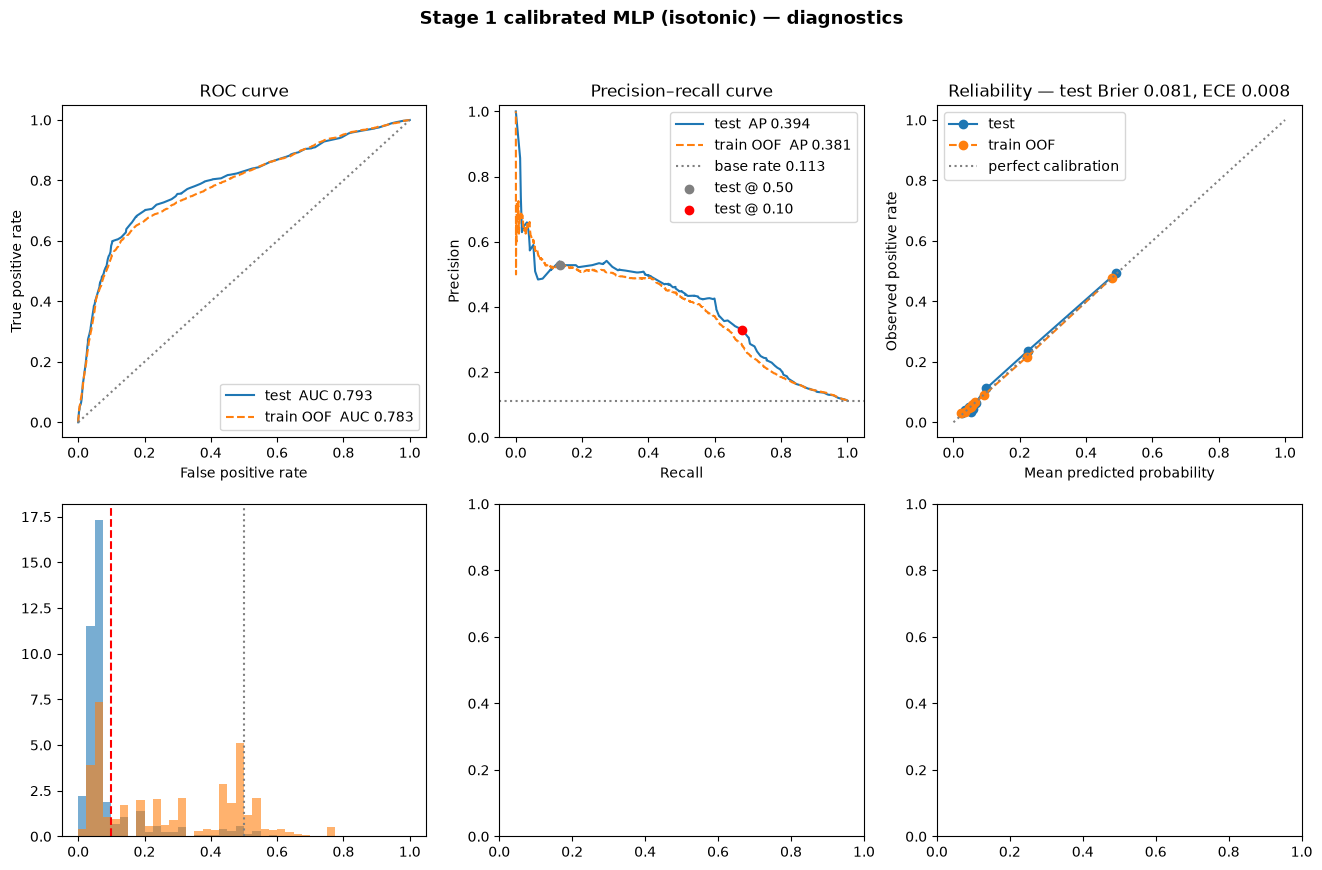

In [13]:
# ============================================================
# CELL 13: PLOT STAGE 1 THRESHOLD AND PROBABILITY DIAGNOSTICS
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
fig.suptitle(f"Stage 1 calibrated MLP ({stage1.calibration_method}) — diagnostics",
             fontsize=13, fontweight="bold")

# ROC
ax = axes[0, 0]
for label, yy, pp, ls, m in (("test", y_te, p_te, "-", m_te_05), ("train OOF", y_tr, p_oof, "--", m_tr_05)):
    fpr, tpr, _ = roc_curve(yy, pp)
    ax.plot(fpr, tpr, ls, label=f"{label}  AUC {m['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], ":", color="grey")
ax.set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
ax.legend(loc="lower right")

# Precision-recall
ax = axes[0, 1]
for label, yy, pp, ls, m in (("test", y_te, p_te, "-", m_te_05), ("train OOF", y_tr, p_oof, "--", m_tr_05)):
    prec, rec, _ = precision_recall_curve(yy, pp)
    ax.plot(rec, prec, ls, label=f"{label}  AP {m['pr_auc']:.3f}")
ax.axhline(y_te.mean(), ls=":", color="grey", label=f"base rate {y_te.mean():.3f}")
ax.scatter(m_te_05["recall"], m_te_05["precision"], color="grey", zorder=5, label="test @ 0.50")
ax.scatter(m_te_thr["recall"], m_te_thr["precision"], color="red", zorder=5, label=f"test @ {thr:.2f}")
ax.set(title="Precision–recall curve", xlabel="Recall", ylabel="Precision", ylim=(0, 1.02))
ax.legend(loc="upper right")

# Reliability (calibrated)
ax = axes[0, 2]
for label, yy, pp, ls in (("test", y_te, p_te, "-"), ("train OOF", y_tr, p_oof, "--")):
    frac_pos, mean_pred = calibration_curve(yy, pp, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o" + ls, label=label)
ax.plot([0, 1], [0, 1], ":", color="grey", label="perfect calibration")
ax.set(title=f"Reliability — test Brier {m_te_05['brier']:.3f}, ECE {m_te_05['ece']:.3f}",
       xlabel="Mean predicted probability", ylabel="Observed positive rate")
ax.legend(loc="upper left")

# Probability distribution by class
ax = axes[1, 0]
bins = np.linspace(0, 1, 41)
ax.hist(p_te[y_te == 0], bins=bins, alpha=0.6, density=True, label="y = 0")
ax.hist(p_te[y_te == 1], bins=bins, alpha=0.6, density=True, label="y = 1")
ax.axvline(0.5, color="grey", ls=":", label="0.50")
ax.axvline(thr, color="red", ls="--", label=f"CV threshold {thr:.2f}")

## Cell 14 — Local threshold tuner

Defines a threshold search over 0.05–0.95 in 0.005 steps, wider and finer than the Stage 1 sweep.

> **Currently unused.** Cell 15 calls the equivalent package function instead. Remove this copy or use it directly to avoid duplicate implementations drifting apart.

In [14]:
# ============================================================
# CELL 14: DEFINE STAGE 1 OOF THRESHOLD TUNING
# ============================================================

from typing import Optional, Tuple
from sklearn.metrics import fbeta_score

def tune_threshold(
    y_true: pd.Series,
    proba: pd.Series,
    beta: float = 2.0,
    grid: Optional[np.ndarray] = None,
) -> Tuple[float, pd.DataFrame]:
    """Threshold maximising F-beta. Pass training (OOF) probabilities only."""
    y = np.asarray(y_true).astype(int)
    p = np.asarray(proba, dtype=float)
    grid = np.round(np.arange(0.05, 0.951, 0.005), 3) if grid is None else np.asarray(grid)
    scores = np.array([
        fbeta_score(y, (p >= t).astype(int), beta=beta, zero_division=0) for t in grid
    ])
    best = int(np.argmax(scores))
    return float(grid[best]), pd.DataFrame({"threshold": grid, "f_beta": scores})

## Cell 15 — Tune and apply the final threshold

Re-tunes the threshold on the wider grid and overwrites `STAGE1_OUTPUT["threshold"]`, `pred_train_oof`, and `pred_test`. Downstream cells therefore use this threshold rather than Cell 9's value.

This creates three important differences:

* The wider search no longer exactly matches the GLASS threshold procedure.
* `stage1.optimal_threshold` retains the original value, while `STAGE1_OUTPUT["threshold"]` holds the final one.
* `stage1_metrics` is rebuilt with different row labels, so Cell 12 must follow a fresh Cell 11 run.

Stage 1 tuned threshold (max F2 on training OOF): 0.100
                   accuracy  precision  recall      f1      f2  roc_auc   brier     ece  pr_auc  pred_pos_rate
train OOF @ 0.5      0.8890     0.5247  0.1519  0.2356  0.1771   0.7829  0.0819  0.0028  0.3814         0.0326
test @ 0.5           0.8891     0.5297  0.1347  0.2148  0.1583   0.7930  0.0806  0.0083  0.3942         0.0286
train OOF @ 0.100    0.8049     0.3201  0.6514  0.4293  0.5397   0.7829  0.0819  0.0028  0.3814         0.2292
test @ 0.100         0.8078     0.3293  0.6810  0.4440  0.5612   0.7930  0.0806  0.0083  0.3942         0.2329


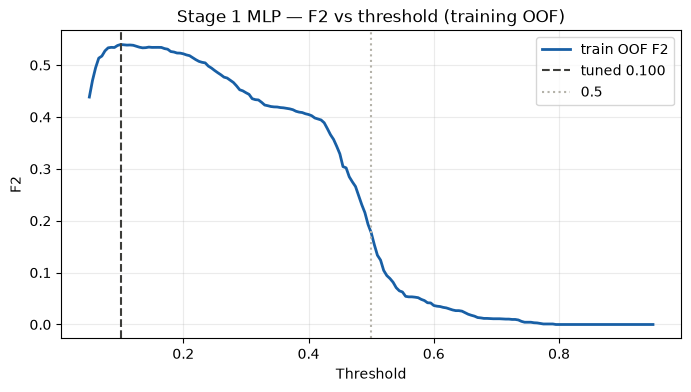

In [15]:
# ============================================================
# CELL 15: TUNE AND EVALUATE STAGE 1 DECISION THRESHOLD
# ============================================================

import importlib
 
import blackbox_pipeline.models.mlp.stage1_mlp as stage1_mlp
 
importlib.reload(stage1_mlp) 
 
STAGE1_THRESHOLD, stage1_threshold_curve = stage1_mlp.tune_threshold(
    STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], beta=2.0,
)
 
STAGE1_OUTPUT["threshold"] = STAGE1_THRESHOLD
STAGE1_OUTPUT["pred_train_oof"] = (
    STAGE1_OUTPUT["proba_train_oof"] >= STAGE1_THRESHOLD
).astype("int8")
STAGE1_OUTPUT["pred_test"] = (
    STAGE1_OUTPUT["proba_test"] >= STAGE1_THRESHOLD
).astype("int8")
 
stage1_metrics = pd.DataFrame({
    "train OOF @ 0.5":
        stage1_mlp.binary_metrics(STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], 0.5),
    "test @ 0.5":
        stage1_mlp.binary_metrics(STAGE1["y_test"], STAGE1_OUTPUT["proba_test"], 0.5),
    f"train OOF @ {STAGE1_THRESHOLD:.3f}":
        stage1_mlp.binary_metrics(STAGE1["y_train"], STAGE1_OUTPUT["proba_train_oof"], STAGE1_THRESHOLD),
    f"test @ {STAGE1_THRESHOLD:.3f}":
        stage1_mlp.binary_metrics(STAGE1["y_test"], STAGE1_OUTPUT["proba_test"], STAGE1_THRESHOLD),
}).T
 
print(f"Stage 1 tuned threshold (max F2 on training OOF): {STAGE1_THRESHOLD:.3f}")
print(stage1_metrics.round(4).to_string())
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(stage1_threshold_curve["threshold"], stage1_threshold_curve["f_beta"],
        color="#185FA5", lw=2, label="train OOF F2")
ax.axvline(STAGE1_THRESHOLD, color="#3d3d3a", ls="--", lw=1.5,
           label=f"tuned {STAGE1_THRESHOLD:.3f}")
ax.axvline(0.5, color="#b4b2a9", ls=":", lw=1.5, label="0.5")
ax.set(title="Stage 1 MLP — F2 vs threshold (training OOF)",
       xlabel="Threshold", ylabel="F2")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Cell 16 — Stage 2 experiment constants

Defines the RF parameter source and tuning budget used by later cells.

* `"artifact"` — load saved RF parameters from `RF_ARTIFACT_DIRS`.
* `"tune"` — run `RF_TUNE_TRIALS` fresh trials.
* `"explicit"` — use `RF_PARAMS_EXPLICIT` directly.

`RF_PASS2_PARAMS = None` reuses Pass 1 hyperparameters for Pass 2. Separate Pass 2 tuning is valid only on its own OOF remainder, not against reported results.

In [16]:
# ============================================================
# CELL 16: STAGE 2 EXPERIMENT CONSTANTS
# ============================================================
 
from pathlib import Path
 
RF_PARAM_SOURCE = "artifact"
 
RF_ARTIFACT_DIRS = [
    GLASS_ROOT / "models" / "rf",
    BLACKBOX_ROOT / "models" / "rf",
    PROTOTYPE_ROOT / "models" / "rf",
]
 
RF_TUNE_TRIALS = 100          
 
RF_PARAMS_EXPLICIT = {        
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 20,
    "max_features": "sqrt",
    "minority_weight": 1.0,
    "class_weight": "balanced",
}
 
RF_PASS2_PARAMS = None
 
assert RF_PARAM_SOURCE in ("artifact", "tune", "explicit"), RF_PARAM_SOURCE
print(f"RF_PARAM_SOURCE = {RF_PARAM_SOURCE!r}")
 

RF_PARAM_SOURCE = 'artifact'


## Cell 17 — Import Stage 2 feature engineering

Imports `glass_brw` RF feature engineering and fixes the shared 29-bin representation.

The assertion ensures Cell 4's Stage 1 `engineer_features` was not accidentally replaced by the RF version. If it fails, re-run Cell 4.

`RF_FEATURES_BINARY` must contain exactly 29 binary features, matching the representation used by both arms.

In [17]:
# ============================================================
# CELL 17: IMPORT STAGE 2 FEATURE ENGINEERING 
# ============================================================
 
import sys
 
 
def _import_brw_feature_engineering():
    """Locate glass_brw's RF feature engineering across both layouts."""
    candidates = (
        "glass_pipeline.glass_brw.rf.feature_engineering",
        "glass_pipeline.glass_brw.feature_engineering",
        "glass_brw.rf.feature_engineering",
        "glass_brw.feature_engineering",
    )
    errors = {}
    for path in candidates:
        try:
            mod = __import__(path, fromlist=["engineer_features"])
            return mod, path
        except ImportError as exc:
            errors[path] = str(exc)
    raise ImportError(
        "Could not import glass_brw RF feature engineering. Tried:\n"
        + "\n".join(f"  {k}: {v}" for k, v in errors.items())
    )
 
 
_brw_fe, _brw_fe_path = _import_brw_feature_engineering()
engineer_rf_features = _brw_fe.engineer_features
RF_SOURCE_FEATURES = list(_brw_fe.RF_SOURCE_FEATURES)
 
_brw_binning = __import__(
    _brw_fe_path.rsplit(".", 1)[0] + ".binning", fromlist=["RF_FEATURES_BINARY"]
)
RF_FEATURES_BINARY = list(_brw_binning.RF_FEATURES_BINARY)
 
print(f"engineer_rf_features ← {_brw_fe.__file__}")
print(f"RF_FEATURES_BINARY   : {len(RF_FEATURES_BINARY)} bins")
assert len(RF_FEATURES_BINARY) == 29, "Expected the locked 29-bin feature list"
 
# Guard against the collision: Stage 1 must still be the LR engineer.
assert engineer_features is not engineer_rf_features, (
    "`engineer_features` (Stage 1 / LR) was overwritten by the RF version — "
    "re-run Cell 4."
)

engineer_rf_features ← C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\glass_brw\rf\feature_engineering.py
RF_FEATURES_BINARY   : 29 bins


## Cell 18 — Build Stage 2 binary features

Fits RF feature engineering on train, applies it to train and test, and stores the result in `BRW_DATA`.

Assertions verify row alignment, exact feature names and order, binary values, and disjoint train/test indices.

Cell 19 repeats key split checks intentionally so failures can be localized to either feature engineering or routing.

In [18]:
# ============================================================
# CELL 18: BUILD STAGE 2 BINARY FEATURES (BRW_DATA)
# ============================================================
 
X_eng_train, X_eng_test = quiet(
    engineer_rf_features,
    GLOBAL_SPLIT["X_train"],
    GLOBAL_SPLIT["X_test"],
    GLOBAL_SPLIT["y_train"],
)
 
BRW_DATA = { 
    "X_eng_train": X_eng_train,
    "X_eng_test": X_eng_test,
    "y_eng_train": GLOBAL_SPLIT["y_train"],
    "y_eng_test": GLOBAL_SPLIT["y_test"],
}
 
# The engineered frames must describe the same rows, in the same order, as the
# split they came from — a reset_index upstream passes a length check and
# silently pairs features with the wrong labels.
assert X_eng_train.index.equals(GLOBAL_SPLIT["X_train"].index)
assert X_eng_test.index.equals(GLOBAL_SPLIT["X_test"].index)
assert list(X_eng_train.columns) == RF_FEATURES_BINARY
assert X_eng_train.isin([0, 1]).all().all() and X_eng_test.isin([0, 1]).all().all()
assert len(X_eng_train.index.intersection(X_eng_test.index)) == 0
 
print(f"BRW_DATA: train {X_eng_train.shape} | test {X_eng_test.shape}")
print(f"train base rate: {BRW_DATA['y_eng_train'].mean():.4f}")

BRW_DATA: train (32950, 29) | test (8238, 29)
train base rate: 0.1127


## Cell 19 — Import the router and verify the shared split

Imports the Stage 2 router and computes `SPLIT_FP`, a fingerprint of the train/test row indices.

The fingerprint is stored with fitted routers and checked on reload, preventing evaluation against a different split that may contain training rows.

`unpack_global_split` also confirms the engineered frames preserve the original row identities and order.

In [19]:
# ============================================================
# CELL 19: IMPORT THE RF ROUTER AND VERIFY THE SHARED SPLIT
# ============================================================

from blackbox_pipeline.models.rf_router.evaluation.router_metrics import (
    compare_routers,
    evaluate_router,
)
from blackbox_pipeline.models.rf_router import (
    OperatingConstraints,
    RFRouter,
    RFRouterConfig,
    SingleRFRouter,
    load_rf_router,
    save_rf_router,
    split_fingerprint,
    unpack_global_split,
)

STAGE2 = unpack_global_split(GLOBAL_SPLIT, engineered=BRW_DATA)
SPLIT_FP = STAGE2["split_fingerprint"]

print(f"split fingerprint : {SPLIT_FP}")
print(f"train / test      : {STAGE2['n_train']:,} / {STAGE2['n_test']:,}")
print(f"rf_router         ← {sys.modules[RFRouter.__module__].__file__}")

split fingerprint : fc3e73a5ef91aea4
train / test      : 32,950 / 8,238
rf_router         ← C:\Users\phill\projects\ai-business-coach\prototype\blackbox_pipeline\models\rf_router\router\two_pass.py


## Cell 20 — Declare the Stage 2 operating constraints

Defines the set-level constraints used to select both router thresholds.

Pass 1 routes `NOT_SUBSCRIBE` with NPV ≥ 0.95 and subscriber leakage ≤ 0.25. Pass 2 routes `SUBSCRIBE` with precision ≥ 0.42 and selects the largest feasible band, maximizing recall subject to that floor.

`recall_denominator="global"` measures Pass 2 recall against all training positives, matching GLASS's reporting convention.

Support floors are set to 125/75, slightly stricter than the GLASS-derived 100/50 defaults.

> GLASS applies constraints per rule, while the RF applies them to the routed set. Compare the measured set-level results from `evaluate_router`, not the configuration values directly.

In [20]:
# ============================================================
# CELL 20: DECLARE THE STAGE 2 OPERATING CONSTRAINTS
# ============================================================
 
CONSTRAINTS = OperatingConstraints(
    min_precision_not_subscribe=0.95,
    max_subscriber_leakage_rate=0.25,
    max_subscriber_leakage_absolute=950,
    min_pass1_coverage=None,
    min_precision_subscribe=0.42,
    min_recall_subscribe=None,
    recall_denominator="global",
    min_band_support_pass1=125,
    min_band_support_pass2=75,
)
 

## Cell 21 — RF parameter normalisation helpers

Defines helpers for loading RF hyperparameters from different saved formats.

`_normalise_rf_params` converts normalized or raw Optuna parameters into the six-key format Stage 2 expects.

`_dig_for_params` searches nested artifacts for that parameter set.

> Falling back to fitted-estimator parameters cannot recover `minority_weight` and substitutes `1.0`. Treat that warning as a signal to locate the original tuned parameters.

In [21]:
# ============================================================
# CELL 21: RESOLVE RF HYPERPARAMETERS
# ============================================================
 
import json
 
REQUIRED_PARAM_KEYS = (
    "n_estimators", "max_depth", "min_samples_leaf",
    "max_features", "minority_weight", "class_weight",
)
 
 
def _normalise_rf_params(raw: dict) -> dict:
    """Accept either normalised params or raw Optuna best_params."""
    if all(k in raw for k in REQUIRED_PARAM_KEYS):
        return {k: raw[k] for k in REQUIRED_PARAM_KEYS}
 
    # Raw Optuna shape — mirrors glass_brw.rf_training._normalize_params
    mf_type = raw.get("max_features_type", "sqrt")
    return {
        "n_estimators": raw["n_estimators"],
        "max_depth": raw.get("max_depth") if raw.get("use_max_depth") else None,
        "min_samples_leaf": raw["min_samples_leaf"],
        "max_features": (raw.get("max_features_fraction")
                         if mf_type == "fraction" else mf_type),
        "minority_weight": raw.get("minority_weight", 1.0),
        "class_weight": "balanced",
    }
 
 
_PARAM_KEYS = ("params", "rf_params", "best_params", "hyperparameters")
 
 
def _dig_for_params(obj, depth: int = 0):
    """
    Find a hyperparameter dict inside an artifact, whatever shape it took.
 
    save_rf_artifact may have pickled the RFResult itself, a dict wrapping it,
    or a dict of plain metadata — and the estimator is also reachable as a last
    resort. Handles all of those rather than assuming one layout.
    """
    if depth > 3 or obj is None:
        return None
 
    # RFResult (or anything else) carrying .params
    p = getattr(obj, "params", None)
    if isinstance(p, dict) and "n_estimators" in p:
        return p
 
    if isinstance(obj, dict):
        for key in _PARAM_KEYS:
            v = obj.get(key)
            if isinstance(v, dict) and "n_estimators" in v:
                return v
        for key in ("rf_result", "result", "model", "rf", "metadata"):
            found = _dig_for_params(obj.get(key), depth + 1)
            if found is not None:
                return found
 
    # Last resort: read them back off the fitted estimator.
    est = obj
    if hasattr(obj, "pipe"):
        est = obj.pipe
    if hasattr(est, "named_steps") and "clf" in getattr(est, "named_steps", {}):
        est = est.named_steps["clf"]
    if hasattr(est, "n_estimators") and hasattr(est, "min_samples_leaf"):
        print("  ⚠️  params read off the fitted estimator, not a stored dict — "
              "minority_weight is not recoverable this way and defaults to 1.0")
        return {
            "n_estimators": est.n_estimators,
            "max_depth": est.max_depth,
            "min_samples_leaf": est.min_samples_leaf,
            "max_features": est.max_features,
            "minority_weight": 1.0,
            "class_weight": "balanced",
        }
    return None
 

## Cell 22 — Artifact parameter loader

Searches `RF_ARTIFACT_DIRS` for saved RF parameters, preferring JSON before joblib or pickle artifacts.

Unreadable files are skipped so one corrupt artifact does not stop the search. If no parameters are found, the error identifies the searched directories and suggests either saving a GLASS RF artifact or switching to `"tune"`.

Joblib files are currently searched by reverse filename order, which assumes timestamp-sortable names. Use modification time instead if filenames are inconsistent.

In [22]:
# ============================================================
# CELL 22: DEFINE RF ARTIFACT PARAMETER LOADER
# ============================================================

def _load_rf_params_from_artifact(dirs) -> tuple[dict, str]:
    """Find params in a saved GLASS RF artifact. JSON first, then joblib."""
    searched = []
 
    for d in dirs:
        d = Path(d)
        searched.append(str(d))
        if not d.is_dir():
            continue
 
        for f in sorted(d.glob("*.json")):
            try:
                blob = json.loads(f.read_text())
            except Exception:
                continue
            for key in ("params", "rf_params", "best_params", "hyperparameters"):
                if isinstance(blob.get(key), dict):
                    return _normalise_rf_params(blob[key]), str(f)
            # some writers nest under a "model"/"rf" section
            for section in ("model", "rf", "metadata"):
                sub = blob.get(section)
                if isinstance(sub, dict) and isinstance(sub.get("params"), dict):
                    return _normalise_rf_params(sub["params"]), str(f)
 
        # Newest first — rf_result_<timestamp>.joblib sorts chronologically.
        blobs = sorted(d.glob("*.joblib"), reverse=True) + \
                sorted(d.glob("*.pkl"), reverse=True)
        for f in blobs:
            try:
                import joblib
                obj = joblib.load(f)
            except Exception as exc:
                print(f"  (could not load {f.name}: "
                      f"{type(exc).__name__}: {exc})")
                continue
            found = _dig_for_params(obj)
            if found is not None:
                return _normalise_rf_params(found), str(f)
 
    raise FileNotFoundError(
        "No RF hyperparameters found. Searched:\n"
        + "\n".join(f"  {s}" for s in searched)
        + "\n\nEither run the GLASS notebook's Cell 12C "
          "(save_rf_artifact) and point RF_ARTIFACT_DIRS at its output, "
          "or set RF_PARAM_SOURCE = 'tune'."
    )

## Cell 23 — Train-only RF tuning

Runs an Optuna search matching `glass_brw._tune_rf`, maximizing mean 5-fold CV ROC-AUC when `RF_PARAM_SOURCE == "tune"`.

Only training data is used; each fold fits on its own training rows and scores held-out rows. The test split never enters tuning.

`n_jobs=1` avoids nested forest parallelism. Tuning uses 5-fold CV to match GLASS, while router OOF scoring uses 10 folds for a separate purpose.

In [23]:
# ============================================================
# CELL 23: DEFINE TRAIN-ONLY RF HYPERPARAMETER TUNING
# ============================================================

def _tune_rf_train_only(X, y, n_trials, random_state=RANDOM_STATE) -> dict:
    """Same search space as glass_brw _tune_rf. X_train only — never test."""
    import optuna
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import StratifiedKFold
    from sklearn.pipeline import Pipeline
 
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
 
    def objective(trial):
        mf_type = trial.suggest_categorical(
            "max_features_type", ["sqrt", "log2", "fraction"])
        use_depth = trial.suggest_categorical("use_max_depth", [True, False])
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 200, 1200, step=50),
            max_depth=trial.suggest_int("max_depth", 2, 12) if use_depth else None,
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
            max_features=(trial.suggest_float("max_features_fraction", 0.3, 1.0)
                          if mf_type == "fraction" else mf_type),
        )
        mw = trial.suggest_float("minority_weight", 1.0, 3.0)
        scores = []
        for tr, va in cv.split(X, y):
            pipe = Pipeline([("clf", RandomForestClassifier(
                **params, class_weight="balanced",
                random_state=random_state, n_jobs=1))])
            pipe.fit(X.iloc[tr], y.iloc[tr],
                     clf__sample_weight=y.iloc[tr].map({0: 1.0, 1: mw}).values)
            scores.append(roc_auc_score(
                y.iloc[va], pipe.predict_proba(X.iloc[va])[:, 1]))
        return float(np.mean(scores))
 
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=random_state),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  best CV ROC-AUC: {study.best_value:.6f}")
    return _normalise_rf_params(study.best_params)

## Cell 24 — Resolve the hyperparameters

Executes the selected parameter source and verifies all six required RF keys are present.

`RF_PARAMS_ORIGIN` records where the parameters came from and should be preserved in artifact metadata for reproducibility.

Pass 1 and Pass 2 share these parameters unless `RF_PASS2_PARAMS` is provided.

In [24]:
# ============================================================
# CELL 24: RESOLVE STAGE 2 RF HYPERPARAMETERS
# ============================================================

if RF_PARAM_SOURCE == "artifact":
    RF_PARAMS, RF_PARAMS_ORIGIN = _load_rf_params_from_artifact(
        RF_ARTIFACT_DIRS
    )

elif RF_PARAM_SOURCE == "tune":
    print(
        f"Tuning on X_train only — "
        f"{RF_TUNE_TRIALS} trials, 5-fold CV"
    )

    RF_PARAMS = _tune_rf_train_only(
        STAGE2["X_train"],
        STAGE2["y_train"],
        RF_TUNE_TRIALS,
    )

    RF_PARAMS_ORIGIN = (
        f"fresh train-only tune ({RF_TUNE_TRIALS} trials)"
    )

else:  # explicit
    RF_PARAMS = _normalise_rf_params(RF_PARAMS_EXPLICIT)
    RF_PARAMS_ORIGIN = "RF_PARAMS_EXPLICIT"

missing = [
    key for key in REQUIRED_PARAM_KEYS
    if key not in RF_PARAMS
]

assert not missing, f"RF_PARAMS missing keys: {missing}"

print(f"\nRF params ← {RF_PARAMS_ORIGIN}")
print(pd.Series(RF_PARAMS).to_string())

print(
    "\nPass 2 forest:",
    "inherits Pass 1 params"
    if RF_PASS2_PARAMS is None
    else "separate params",
)


RF params ← C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\models\rf\rf_result_20260530_015135.joblib
n_estimators             650
max_depth                  5
min_samples_leaf          14
max_features        0.624279
minority_weight     1.458226
class_weight        balanced

Pass 2 forest: inherits Pass 1 params


## Cell 25 — Experiment 1: single-RF ablation

Fits one RF and applies two thresholds to the same score. This is an ablation, not the final Stage 2 architecture.

Because both cuts share one score, their ordering matters. If `t1 > t2`, the abstain region disappears, so the solver raises rather than silently clipping the thresholds.

Uses 10-fold OOF probabilities for threshold selection, then refits on the full training set.

In [25]:
# ============================================================
# CELL 25: EXPERIMENT 1 — SINGLE-RF TWO-THRESHOLD ABLATION
# ============================================================
 
ablation_config = RFRouterConfig(
    mode="single_rf",
    constraints=CONSTRAINTS,
    rf_params=RF_PARAMS,
    n_oof_folds=10,
    random_state=RANDOM_STATE,
    verbose=True,
)
 
ablation = SingleRFRouter(ablation_config).fit(
    STAGE2["X_train"], STAGE2["y_train"], SPLIT_FP,
)


── single-RF ablation ──────────────────────────────────
  out-of-fold scoring
   single-RF OOF: 32,950 rows, 10 folds
      fold 1/10: fit 29,655 → scored 3,295
      fold 2/10: fit 29,655 → scored 3,295
      fold 3/10: fit 29,655 → scored 3,295
      fold 4/10: fit 29,655 → scored 3,295
      fold 5/10: fit 29,655 → scored 3,295
      fold 6/10: fit 29,655 → scored 3,295
      fold 7/10: fit 29,655 → scored 3,295
      fold 8/10: fit 29,655 → scored 3,295
      fold 9/10: fit 29,655 → scored 3,295
      fold 10/10: fit 29,655 → scored 3,295
  solving thresholds (train OOF only)
   t1 = 0.360746 | routes 20,058 (60.9%) | NPV 0.9538 | leaks 927 subs (24.97%)
   t2 = 0.668089 | flags 5,047 (15.3% of its population) | precision 0.4201 | recall 0.5711 (global denominator)
  refitting on the full training split
  RF ROUTER — single_rf (ablation)
  train rows          : 32,950
  training base rate  : 0.1127
  split fingerprint   : fc3e73a5ef91aea4
  t1 (route < t1)     : 0.360746
  t2 (fl

## Cell 26 — Experiment 2: two-pass RF router

Implements the GLASS-like two-pass structure: Pass 1 routes `NOT_SUBSCRIBE`, Pass 2 trains on the OOF-defined remainder and routes `SUBSCRIBE`, and unresolved rows abstain.

No threshold-order check is needed because the two thresholds act on different models and populations.

`validate_nested=True` checks the remaining dependence from using a globally selected Pass 1 threshold to define the remainder. The nested protocol re-derives that threshold inside each outer fold so a scored row cannot influence its own prediction.

> **Cost:** roughly 142 forest fits at 500 trees. Use `VALIDATE_NESTED = False` during iteration and enable it for the reported run.

A `consistent` verdict supports reporting the cheaper path with the nested check documented. `DIVERGENT` means the nested results should be reported instead.

In [26]:
# ============================================================
# CELL 26: EXPERIMENT 2 — TWO-PASS RF ROUTER 
# ============================================================
 
VALIDATE_NESTED = True
 
router_config = RFRouterConfig(
    mode="two_pass",
    constraints=CONSTRAINTS,
    rf_params=RF_PARAMS,
    pass2_rf_params=None,          # None reuses RF_PARAMS for the Pass 2 forest
    n_oof_folds=10,
    n_inner_folds=5,
    random_state=RANDOM_STATE,
    remainder_min_size=500,
    validate_nested=VALIDATE_NESTED,
    verbose=True,
)
 
router = RFRouter(router_config).fit(
    STAGE2["X_train"], STAGE2["y_train"], SPLIT_FP,
)
 
if router.fit_report_.nested_check:
    print("\nNested cascade check:")
    print(pd.Series(router.fit_report_.nested_check).to_string())


── two-pass RF router ──────────────────────────────────
  [1/6] Pass 1 out-of-fold scoring
   pass1 OOF: 32,950 rows, 10 folds
      fold 1/10: fit 29,655 → scored 3,295
      fold 2/10: fit 29,655 → scored 3,295
      fold 3/10: fit 29,655 → scored 3,295
      fold 4/10: fit 29,655 → scored 3,295
      fold 5/10: fit 29,655 → scored 3,295
      fold 6/10: fit 29,655 → scored 3,295
      fold 7/10: fit 29,655 → scored 3,295
      fold 8/10: fit 29,655 → scored 3,295
      fold 9/10: fit 29,655 → scored 3,295
      fold 10/10: fit 29,655 → scored 3,295
  [2/6] solving t1 (train OOF only)
   t1 = 0.360746 | routes 20,058 (60.9%) | NPV 0.9538 | leaks 927 subs (24.97%)
  [3/6] remainder: 12,892 rows (39.1%) survive Pass 1
  [4/6] Pass 2 out-of-fold scoring within the remainder
   pass2 OOF: 12,892 rows, 10 folds
      fold 1/10: fit 11,602 → scored 1,290
      fold 2/10: fit 11,602 → scored 1,290
      fold 3/10: fit 11,603 → scored 1,289
      fold 4/10: fit 11,603 → scored 1,289
      

## Cell 27 — Inspect the frozen operating point

Plots both OOF threshold sweeps against routed coverage. No test data is used.

Pass 1 selects the largest `t1` satisfying the NPV floor and leakage cap, maximizing routed coverage. Pass 2 selects the smallest `t2` satisfying the precision floor, maximizing recall within the remainder.

The printed tails show the final feasible bands and nearby alternatives; `binding` identifies the constraint that rejected infeasible rows.

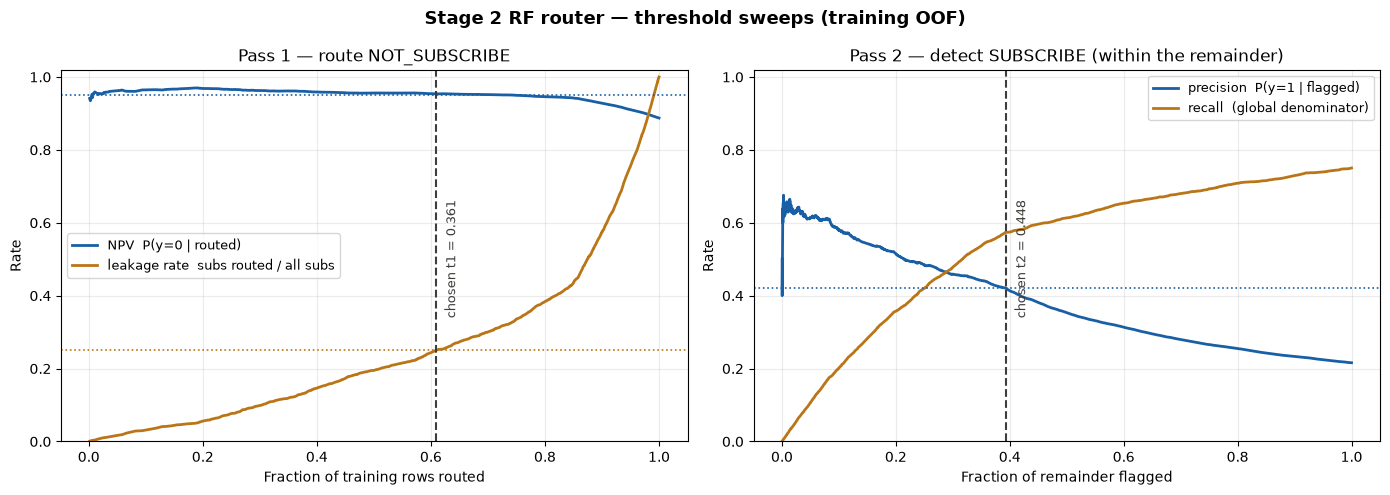

Which constraint binds at the chosen band:
 band_size  coverage    npv  subscribers_routed  leakage_rate  threshold  feasible binding
     19997    0.6069 0.9538                 923        0.2487     0.3601      True        
     20056    0.6087 0.9538                 927        0.2497     0.3606      True        
     20058    0.6087 0.9538                 927        0.2497     0.3607      True        

 band_size  band_fraction  precision  positives_in_band  recall  threshold  feasible binding
      5067         0.3930     0.4204               2130  0.5738     0.4572      True        
      5068         0.3931     0.4203               2130  0.5738     0.4566      True        
      5069         0.3932     0.4202               2130  0.5738     0.4481      True        


In [27]:
# ============================================================
# CELL 27: INSPECT THE FROZEN OPERATING POINT (TRAINING OOF ONLY)
# ============================================================
 
import matplotlib.pyplot as plt

p1_sweep = router.thresholds_.pass1.sweep
p2_sweep = router.thresholds_.pass2.sweep
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stage 2 RF router — threshold sweeps (training OOF)",
             fontsize=13, fontweight="bold")
 
# --- Pass 1: NPV and leakage against how much the route claims --------------
ax = axes[0]
ax.plot(p1_sweep["coverage"], p1_sweep["npv"],
        color="#185FA5", lw=2, label="NPV  P(y=0 | routed)")
ax.plot(p1_sweep["coverage"], p1_sweep["leakage_rate"],
        color="#BA7517", lw=2, label="leakage rate  subs routed / all subs")
ax.axhline(CONSTRAINTS.min_precision_not_subscribe,
           color="#185FA5", ls=":", lw=1.2)
ax.axhline(CONSTRAINTS.max_subscriber_leakage_rate,
           color="#BA7517", ls=":", lw=1.2)
ax.axvline(router.thresholds_.pass1.band_fraction,
           color="#3d3d3a", ls="--", lw=1.5)
ax.annotate(f"chosen t1 = {router.thresholds_.t1:.3f}",
            xy=(router.thresholds_.pass1.band_fraction, 0.5),
            xytext=(6, 0), textcoords="offset points",
            fontsize=9, color="#3d3d3a", rotation=90, va="center")
ax.set(title="Pass 1 — route NOT_SUBSCRIBE",
       xlabel="Fraction of training rows routed", ylabel="Rate", ylim=(0, 1.02))
ax.grid(alpha=0.25)
ax.legend(loc="center left", fontsize=9)
 
# --- Pass 2: precision and recall against how much the detector flags -------
ax = axes[1]
ax.plot(p2_sweep["band_fraction"], p2_sweep["precision"],
        color="#185FA5", lw=2, label="precision  P(y=1 | flagged)")
ax.plot(p2_sweep["band_fraction"], p2_sweep["recall"],
        color="#BA7517", lw=2, label=f"recall  ({CONSTRAINTS.recall_denominator} denominator)")
ax.axhline(CONSTRAINTS.min_precision_subscribe, color="#185FA5", ls=":", lw=1.2)
if CONSTRAINTS.min_recall_subscribe is not None:
    ax.axhline(CONSTRAINTS.min_recall_subscribe, color="#BA7517", ls=":", lw=1.2)
ax.axvline(router.thresholds_.pass2.band_fraction,
           color="#3d3d3a", ls="--", lw=1.5)
ax.annotate(f"chosen t2 = {router.thresholds_.t2:.3f}",
            xy=(router.thresholds_.pass2.band_fraction, 0.5),
            xytext=(6, 0), textcoords="offset points",
            fontsize=9, color="#3d3d3a", rotation=90, va="center")
ax.set(title="Pass 2 — detect SUBSCRIBE (within the remainder)",
       xlabel="Fraction of remainder flagged", ylabel="Rate", ylim=(0, 1.02))
ax.grid(alpha=0.25)
ax.legend(loc="upper right", fontsize=9)
 
plt.tight_layout()
plt.show()
 
print("Which constraint binds at the chosen band:")
print(p1_sweep[p1_sweep["feasible"]].tail(3).round(4).to_string(index=False))
print()
print(p2_sweep[p2_sweep["feasible"]].tail(3).round(4).to_string(index=False))

## Cell 28 — Training-OOF sanity check

Compares the single-RF ablation and two-pass router on the same training split and constraints.

Because both arms use identical data and operating requirements, differences here reflect architecture rather than split differences.

The fingerprint assertion verifies both routers were fitted on the current split. A mismatch invalidates downstream comparisons.

In [28]:
# ============================================================
# CELL 28: TRAINING-OOF SANITY CHECK (STILL NO TEST DATA)
# ============================================================
 
_train_oof_summary = pd.DataFrame({
    "single_rf": {
        "t1": ablation.thresholds_.t1,
        "t2": ablation.thresholds_.t2,
        "pass1 band frac": ablation.thresholds_.pass1.band_fraction,
        "pass1 NPV (OOF)": ablation.bands_.pass1_confidence,
        "pass1 leakage (OOF)": ablation.thresholds_.pass1.leakage_rate,
        "pass2 band frac": ablation.thresholds_.pass2.band_fraction,
        "pass2 precision (OOF)": ablation.bands_.pass2_confidence,
        "pass2 recall (OOF)": ablation.thresholds_.pass2.recall,
        "remainder frac": float("nan"),
    },
    "two_pass": {
        "t1": router.thresholds_.t1,
        "t2": router.thresholds_.t2,
        "pass1 band frac": router.thresholds_.pass1.band_fraction,
        "pass1 NPV (OOF)": router.bands_.pass1_confidence,
        "pass1 leakage (OOF)": router.thresholds_.pass1.leakage_rate,
        "pass2 band frac": router.thresholds_.pass2.band_fraction,
        "pass2 precision (OOF)": router.bands_.pass2_confidence,
        "pass2 recall (OOF)": router.thresholds_.pass2.recall,
        "remainder frac": router.fit_report_.remainder["fraction"],
    },
})
print(_train_oof_summary.round(4).to_string())
 
assert ablation.is_fitted and router.is_fitted
assert ablation.split_fingerprint_ == router.split_fingerprint_ == SPLIT_FP
print("\n✅ both operating points frozen; fingerprints match the shared split")

                       single_rf  two_pass
t1                        0.3607    0.3607
t2                        0.6681    0.4481
pass1 band frac           0.6087    0.6087
pass1 NPV (OOF)           0.9538    0.9538
pass1 leakage (OOF)       0.2497    0.2497
pass2 band frac           0.1532    0.3932
pass2 precision (OOF)     0.4201    0.4202
pass2 recall (OOF)        0.5711    0.5738
remainder frac               NaN    0.3913

✅ both operating points frozen; fingerprints match the shared split


## Cell 29 — Pass 1 vs Pass 2 agreement

Measures whether Pass 2 learns a meaningfully different ranking from Pass 1.

High agreement suggests the two-pass RF is largely redundant. Lower agreement indicates remainder training changed the ordering and supports the structural role of Pass 2.

This is an architecture diagnostic, not a performance metric.

In [29]:
# ============================================================
# CELL 29 Pass 1 Vs 2 Agreement Analysis
# ============================================================

import numpy as np
rem = router.remainder_mask_
p1 = router.oof_pass1_proba_[rem]
p2 = router.oof_pass2_proba_[rem]
print(f"spearman(p1, p2) on remainder : {pd.Series(p1).corr(pd.Series(p2), method='spearman'):.4f}")
print(f"pass2 flagged by p2 > t2      : {(p2 > router.thresholds_.t2).sum():,}")
print(f"same rows by p1 rank          : {(p1 > np.quantile(p1, 1 - (p2 > router.thresholds_.t2).mean())).sum():,}")
print(f"agreement                     : {((p2 > router.thresholds_.t2) == (p1 > np.quantile(p1, 1 - (p2 > router.thresholds_.t2).mean()))).mean():.4f}")

spearman(p1, p2) on remainder : 0.9759
pass2 flagged by p2 > t2      : 5,069
same rows by p1 rank          : 5,067
agreement                     : 0.9975


## Cell 30 — Test evaluation

The only Stage 2 cell that uses the test split. Thresholds were already frozen in Cells 25 and 26.

Assertions verify the split fingerprint and train/test disjointness before evaluation.

Both routers use `evaluate_router`, keeping metrics and denominators consistent. Interpret `pass1_leakage_rate` and `pass2_precision` as set-level results; GLASS's configured limits are per-rule.

In [30]:
# ============================================================
# CELL 30: TEST EVALUATION 
# ============================================================
 
assert split_fingerprint(STAGE2["X_train"], STAGE2["X_test"]) == SPLIT_FP
assert len(STAGE2["X_train"].index.intersection(STAGE2["X_test"].index)) == 0
 
stage2_results = compare_routers(
    evaluate_router(
        *ablation.predict(STAGE2["X_test"]), STAGE2["y_test"],
        label="RF single (ablation)",
        base_rate=ablation.training_base_rate,
    ),
    evaluate_router(
        *router.predict(STAGE2["X_test"]), STAGE2["y_test"],
        label="RF two-pass",
        base_rate=router.training_base_rate,
    ),
)
 
HEADLINE = [
    "coverage", "abstain_rate",
    "pass1_share", "pass1_npv", "pass1_subscribers_lost", "pass1_leakage_rate",
    "pass2_share", "pass2_precision", "pass2_recall",
    "abstain_base_rate", "resolved_accuracy", "resolved_f1",
]
 
print("Stage 2 — test split, set-level metrics")
print(stage2_results.loc[HEADLINE].round(4).to_string())

Stage 2 — test split, set-level metrics
                        RF single (ablation)  RF two-pass
coverage                              0.7613       0.7615
abstain_rate                          0.2387       0.2385
pass1_share                           0.6085       0.6085
pass1_npv                             0.9597       0.9597
pass1_subscribers_lost              202.0000     202.0000
pass1_leakage_rate                    0.2177       0.2177
pass2_share                           0.1528       0.1529
pass2_precision                       0.4400       0.4389
pass2_recall                          0.5970       0.5959
abstain_base_rate                     0.0875       0.0880
resolved_accuracy                     0.8554       0.8551
resolved_f1                           0.5499       0.5489


## Cell 31 — Save the routers

Saves both routers with thresholds, band statistics, configuration, constraints, split fingerprint, and threshold sweeps.

`test_metrics` is stored only for reporting and never feeds back into fitting or threshold selection.

The reload check verifies the artifact against `expected_split_fingerprint`, preventing later evaluation on a different split.

> Keep `STAGE2_OUT` outside the source package so artifacts do not mix with code.

In [31]:
# ============================================================
# CELL 31: SAVE THE ROUTERS
# ============================================================
 
STAGE2_OUT = "./models/rf_router"
 
_ = save_rf_router(
    ablation, STAGE2_OUT, name="rf_router_single",
    test_metrics=stage2_results["RF single (ablation)"].to_dict(),
)
_ = save_rf_router(
    router, STAGE2_OUT, name="rf_router_two_pass",
    test_metrics=stage2_results["RF two-pass"].to_dict(),
)
 
# Reload guard
_reloaded = load_rf_router(
    f"{STAGE2_OUT}/rf_router_two_pass.joblib",
    expected_split_fingerprint=SPLIT_FP,
)
print(f"\nreload OK — t1={_reloaded['thresholds']['t1']:.6f} "
      f"t2={_reloaded['thresholds']['t2']:.6f}")
 

✅ saved single_rf router → models\rf_router\rf_router_single.joblib
   metadata     : models\rf_router\rf_router_single_metadata.json
   threshold sweeps written alongside
✅ saved two_pass router → models\rf_router\rf_router_two_pass.joblib
   metadata     : models\rf_router\rf_router_two_pass_metadata.json
   threshold sweeps written alongside

reload OK — t1=0.360746 t2=0.448120


## Cell 32 — Package outputs for Stage 3

Builds the Stage 3 handoff using OOF train predictions and fitted-model test predictions.

Train outputs come from `predict_train_oof()`, ensuring each row was scored by a model that did not train on it. Using `predict(X_train)` would contaminate downstream stacking.

The assertion checks that OOF and in-sample abstain masks differ, confirming the OOF path is active. Printed abstain rates show how enriched the unresolved region is for Stage 3.

In [32]:
# ============================================================
# CELL 32: PACKAGE STAGE 2 OUTPUTS FOR STAGE 3
# ============================================================

_p_tr, _c_tr, _d_tr = router.predict_train_oof()
_p_te, _c_te, _d_te = router.predict(STAGE2["X_test"])

_idx_tr, _idx_te = STAGE2["X_train"].index, STAGE2["X_test"].index

STAGE2_OUTPUT = {
    "router": router,
    "ablation": ablation,
    "t1": router.thresholds_.t1,
    "t2": router.thresholds_.t2,
    "preds_train_oof": pd.Series(_p_tr, index=_idx_tr),
    "conf_train_oof": pd.Series(_c_tr, index=_idx_tr),
    "decisions_train_oof": pd.Series(_d_tr, index=_idx_tr),
    "preds_test": pd.Series(_p_te, index=_idx_te),
    "conf_test": pd.Series(_c_te, index=_idx_te),
    "decisions_test": pd.Series(_d_te, index=_idx_te),
    "proba_test": router.predict_proba(STAGE2["X_test"]),
    "metrics_test": stage2_results,
    "split_fingerprint": SPLIT_FP,
}

STAGE2_OUTPUT["abstain_train"] = STAGE2_OUTPUT["decisions_train_oof"] == "uncertain"
STAGE2_OUTPUT["abstain_test"] = STAGE2_OUTPUT["decisions_test"] == "uncertain"

_in_sample = (router.predict(STAGE2["X_train"])[2] == "uncertain")
_oof_ab = STAGE2_OUTPUT["abstain_train"].values
print(f"abstain mask — OOF {_oof_ab.sum():,} vs in-sample {_in_sample.sum():,} "
      f"| agreement {(_oof_ab == _in_sample).mean():.4f}")
assert not np.array_equal(_oof_ab, _in_sample), \
    "OOF and in-sample abstain masks identical — OOF path not being used"

print(f"\nStage 2 → Stage 3 handoff")
print(f"  train abstains (OOF): {_oof_ab.sum():,} ({_oof_ab.mean():.1%})")
print(f"  test  abstains      : {STAGE2_OUTPUT['abstain_test'].sum():,} "
      f"({STAGE2_OUTPUT['abstain_test'].mean():.1%})")
print(f"  train abstain base rate: "
      f"{STAGE2['y_train'][_oof_ab].mean():.4f}")
print(f"  test  abstain base rate: "
      f"{STAGE2['y_test'][STAGE2_OUTPUT['abstain_test']].mean():.4f}")
 

abstain mask — OOF 7,823 vs in-sample 7,957 | agreement 0.9692

Stage 2 → Stage 3 handoff
  train abstains (OOF): 7,823 (23.7%)
  test  abstains      : 1,965 (23.9%)
  train abstain base rate: 0.0837
  test  abstain base rate: 0.0880


## Cell 33 — Stage 3 experiment constants

`XGB_PARAM_SOURCE` selects the XGBoost hyperparameter source:

| Value        | Behaviour                                           |
| ------------ | --------------------------------------------------- |
| `"tune"`     | Run `XGB_TUNE_TRIALS` Optuna trials                 |
| `"explicit"` | Use `XGB_PARAMS_EXPLICIT` directly                  |
| `"artifact"` | Load `best_params` from the newest Stage 3 artifact |

Artifact parameters are valid only for the same split and feature contract.

`_newest()` selects the most recently modified artifact across `XGB_ARTIFACT_DIRS`, excluding `*_latest` copies.

In [ ]:
# ============================================================
# CELL 33: STAGE 3 EXPERIMENT CONSTANTS
# ============================================================
from pathlib import Path

XGB_PARAM_SOURCE = "tune"            # "artifact" | "tune" | "explicit"

XGB_ARTIFACT_DIRS = [
    GLASS_ROOT / "models" / "xgb",
    BLACKBOX_ROOT / "models" / "xgb",
    PROTOTYPE_ROOT / "models" / "xgb",
]

XGB_TUNE_TRIALS = 150                # MIRROR — the EBM's Optuna budget

XGB_PARAMS_EXPLICIT = {              # read only when XGB_PARAM_SOURCE == "explicit"
    "n_estimators": 600,
    "learning_rate": 0.02,
    "max_depth": 4,
    "min_child_weight": 5.0,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0,
}


def _newest(dirs, pattern):
    """Newest file by modification time across ALL dirs; skips *_latest copies."""
    found = [p for d in map(Path, dirs) if d.exists()
             for p in d.glob(pattern) if not p.stem.endswith("_latest")]
    return max(found, key=lambda p: p.stat().st_mtime) if found else None


assert XGB_PARAM_SOURCE in ("artifact", "tune", "explicit"), XGB_PARAM_SOURCE
print(f"XGB_PARAM_SOURCE = {XGB_PARAM_SOURCE!r}")


XGB_PARAM_SOURCE = 'tune'


## Cell 34 — Stage 3 feature block

Both arms use the same GLASS feature pipeline:

`drop_leaky_features` → `engineer_ebm_features` → `select_ebm_features`

The black-box arm performs no independent feature engineering.

Assertions verify exact `EBM_FEATURES` order and alignment with `GLOBAL_SPLIT`. Only `y_train` is passed into feature engineering.

In [ ]:
# ============================================================
# CELL 34: STAGE 3 FEATURE BLOCK — ONE RUN OF THE GLASS DAG
# ============================================================
from glass_pipeline.ebm.feature_engineering import (
    EBM_FEATURES,
    drop_leaky_features,
    engineer_ebm_features,
    select_ebm_features,
)

_Xtr = GLOBAL_SPLIT["X_train"].copy()
_Xte = GLOBAL_SPLIT["X_test"].copy()

_Xtr, _Xte = quiet(drop_leaky_features, _Xtr, _Xte)
_Xtr, _Xte, _added = quiet(
    engineer_ebm_features, _Xtr, _Xte, GLOBAL_SPLIT["y_train"]
)
_Xtr, _Xte = quiet(select_ebm_features, _Xtr, _Xte)

STAGE3_DATA = {"X_stage3_train": _Xtr, "X_stage3_test": _Xte}

assert list(_Xtr.columns) == list(EBM_FEATURES)
assert _Xtr.index.equals(GLOBAL_SPLIT["X_train"].index)
assert _Xte.index.equals(GLOBAL_SPLIT["X_test"].index)
print(f"Stage 3 block: {len(EBM_FEATURES)} features, "
      f"train {_Xtr.shape}, test {_Xte.shape}")
print(f"   {list(EBM_FEATURES)}")

Stage 3 block: 13 features, train (32950, 13), test (8238, 13)
   ['decay_x_density', 'euribor3m_sigmoid_slope', 'economic_curvature_intensity', 'cons.conf.idx', 'age', 'dow_month_encoded', 'default', 'prior_x_stress', 'campaign', 'overlap_default_clean', 'cpi_high_cellular', 'behavioral_favorability', 'emp_var_rate_sigmoid_slope']


## Cell 35 — Stage 3 XGBoost

Trains the black-box counterpart to EBM while matching the split, features, seed, weighting, tuning objective, CV reporting, calibration rule, and threshold grid.

Training-side procedure:

1. Validate features and impute with train medians.
2. Build balanced weights and shared CV folds.
3. Tune with Optuna when required.
4. Produce the 10-fold CV report.
5. Refit on the full training set.
6. Generate OOF predictions for Stage 4.
7. Apply fold-nested isotonic calibration when OOF ECE > 0.05.
8. Select thresholds from OOF predictions.
9. Evaluate on test after all operating choices are frozen.

Recorded departures from GLASS include OOF-based thresholding and calibration, OOF Stage 4 outputs, train-derived imputation, and an XGBoost-specific search space.

`split_fingerprint` is stored for validation in Cell 38.

In [ ]:
# ============================================================
# CELL 35: STAGE 3 — XGBOOST
# ============================================================
import joblib
from blackbox_pipeline.models.xgb import XGBStage3Config, train_xgb_stage

_FP_NOW = split_fingerprint(GLOBAL_SPLIT["X_train"], GLOBAL_SPLIT["X_test"])

_params, _params_source = None, None
if XGB_PARAM_SOURCE == "explicit":
    _params, _params_source = dict(XGB_PARAMS_EXPLICIT), "XGB_PARAMS_EXPLICIT"
elif XGB_PARAM_SOURCE == "artifact":
    _src = _newest(XGB_ARTIFACT_DIRS, "xgb_stage3_*.joblib")
    if _src is None:
        raise FileNotFoundError(
            f"XGB_PARAM_SOURCE='artifact' but no xgb_stage3_*.joblib in "
            f"{[str(d) for d in XGB_ARTIFACT_DIRS]}. Use 'tune' first."
        )
    _prev = joblib.load(_src)
    if _prev.split_fingerprint != _FP_NOW:
        raise ValueError(
            f"{_src.name} was tuned on a different split "
            f"({_prev.split_fingerprint!r} vs current {_FP_NOW!r}). "
            "Re-tune with XGB_PARAM_SOURCE='tune'."
        )
    if list(_prev.features) != list(EBM_FEATURES):
        raise ValueError(
            f"{_src.name} was tuned on a different feature contract. "
            "Re-tune with XGB_PARAM_SOURCE='tune'."
        )
    _params = dict(_prev.best_params)
    _params_source = (f"artifact {_src.name} "
                      f"(tuned CV F2 {_prev.cv_score:.6f})")
    print(f"params ← {_params_source}")

XGB_STAGE3_CONFIG = XGBStage3Config(
    expected_features=list(EBM_FEATURES),   # enforces the EBM contract
    n_trials=XGB_TUNE_TRIALS,
    artifact_dir=str(BLACKBOX_ROOT / "models" / "xgb"),
    verbose=True,
)

XGB_STAGE3, XGB_STAGE3_PATH = train_xgb_stage(
    GLOBAL_SPLIT,
    engineered=STAGE3_DATA,
    config=XGB_STAGE3_CONFIG,
    params=_params,
    params_source=_params_source,
    split_fingerprint=_FP_NOW,
)


  STAGE 3 — XGBOOST  (counterpart of glass_pipeline.ebm)
  train 32,950 rows | test 8,238 rows | 13 features
  balanced sample weights: class 0 → 0.5635, class 1 → 4.4383 (positive class upweighted 7.9×)
  fold plan: 5-fold stratified, seed 42 (shared by tuning, OOF, calibration and threshold selection)

  XGBOOST STAGE 3 TUNING — RECALL-BIASED (F2 objective)
  dataset      : 32,950 rows, 13 features
  class balance: {0: 29238, 1: 3712}
  balanced sample weights: class 0 → 0.5635, class 1 → 4.4383 (positive class upweighted 7.9×)
  objective    : F2 at the 0.5 cut (same as the EBM's model.predict)
  folds        : 5-fold stratified, seed 42
  budget       : 150 trials, TPE(seed=42), MedianPruner(20/2)
  search space :
           n_estimators  int[200, 2000] step 100
          learning_rate  float[0.005, 0.05] log
              max_depth  int[2, 8]
       min_child_weight  float[1.0, 20.0] log
              subsample  float[0.6, 1.0]
       colsample_bytree  float[0.6, 1.0]
           

  0%|          | 0/150 [00:00<?, ?it/s]


------------------------------------------------------------------------------
best CV F2 : 0.557038
trials     : 94 completed, 56 pruned, 0 failed of 150
runtime    : 3070.2s
best params:
         n_estimators = 1700
        learning_rate = 0.005895
            max_depth = 5
     min_child_weight = 6.084693
            subsample = 0.864551
     colsample_bytree = 0.915105
           reg_lambda = 0.002729
------------------------------------------------------------------------------

  10-fold cross-validation (final evaluation, seed 42)
     fold  1: AUC=0.7940  Recall=0.6415  Precision=0.3826  F1=0.4794  F2=0.5651
     fold  2: AUC=0.7775  Recall=0.6173  Precision=0.3742  F1=0.4659  F2=0.5463
     fold  3: AUC=0.8218  Recall=0.6739  Precision=0.3828  F1=0.4883  F2=0.5849
     fold  4: AUC=0.7799  Recall=0.5876  Precision=0.3907  F1=0.4693  F2=0.5338
     fold  5: AUC=0.7980  Recall=0.6280  Precision=0.3669  F1=0.4632  F2=0.5498
     fold  6: AUC=0.7970  Recall=0.6280  Precision=0.39

## Cell 36 — Stage 4 hand-off

| Accessor              | Source                | Use              |
| --------------------- | --------------------- | ---------------- |
| `stage4_frame()`      | OOF train predictions | Train Stage 4    |
| `stage4_test_frame()` | Refit model on test   | Evaluate Stage 4 |

Both expose `proba`, `proba_calibrated`, `decision`, `confidence`, `margin`, `state`, and `fold_id`.

Train outputs are leakage-safe: probabilities are OOF, calibration is fold-nested, and decisions use per-fold thresholds chosen without that fold's labels.

Do not train Stage 4 on `refit["train_proba"]`; it is in-sample and diagnostic only.

Threshold spread measures stability. OOF F2 using a threshold selected on the same rows is mildly optimistic.

In [ ]:
# ============================================================
# CELL 36: STAGE 4 HAND-OFF — OOF vs REFIT
# ============================================================
STAGE3_XGB_TRAIN = XGB_STAGE3.stage4_frame()        # leakage-safe
STAGE3_XGB_TEST = XGB_STAGE3.stage4_test_frame()

assert STAGE3_XGB_TRAIN.index.equals(GLOBAL_SPLIT["X_train"].index)
assert STAGE3_XGB_TEST.index.equals(GLOBAL_SPLIT["X_test"].index)

print(STAGE3_XGB_TRAIN.head())
print(f"\ntrain side {STAGE3_XGB_TRAIN.shape} | test side {STAGE3_XGB_TEST.shape}")

# How much optimism the in-sample column would have carried into Stage 4
from sklearn.metrics import roc_auc_score
_y = GLOBAL_SPLIT["y_train"]
_auc_oof = roc_auc_score(_y, XGB_STAGE3.oof["proba"])
_auc_ins = roc_auc_score(_y, XGB_STAGE3.refit["train_proba"])
print(f"\ntrain AUC  OOF {_auc_oof:.4f}  |  in-sample {_auc_ins:.4f}  "
      f"|  optimism {_auc_ins - _auc_oof:+.4f}")

# Operating-point stability and honest OOF performance
_nest = XGB_STAGE3.threshold["oof_nested"]
_m_sel = XGB_STAGE3.metrics["oof_at_operating_threshold"]
_m_nst = XGB_STAGE3.metrics["oof_at_nested_thresholds"]
print(f"\nthreshold  global {XGB_STAGE3.threshold['oof']['threshold']:.4f}  |  "
      f"per-fold {_nest['by_fold']}  (sd {_nest['std']:.4f})")
print(f"OOF F2     in-selection {_m_sel['f2']:.4f}  |  "
      f"fold-nested {_m_nst['f2']:.4f}")

# Calibration: GLASS-parity ECE vs every-row ECE
_cal = XGB_STAGE3.calibration
print(f"calibration {'applied' if _cal['applied'] else 'skipped'}  |  "
      f"ECE {_cal['ece_before']:.4f} → {_cal['ece_after']:.4f}  |  "
      f"all-rows {_cal['ece_before_full']:.4f} → {_cal['ece_after_full']:.4f}  "
      f"({_cal['n_zero_after']} rows at p=0)")

       xgb_stage3_proba  xgb_stage3_proba_calibrated  xgb_stage3_decision  \
25611          0.151253                     0.030978                    0   
26010          0.235284                     0.041237                    0   
40194          0.936823                     0.687671                    1   
297            0.154370                     0.033566                    0   
36344          0.797444                     0.306854                    1   

       xgb_stage3_confidence  xgb_stage3_margin xgb_stage3_state  \
25611               0.697493          -0.348747      not_flagged   
26010               0.529432          -0.264716      not_flagged   
40194               0.873646           0.436823          flagged   
297                 0.691259          -0.345630      not_flagged   
36344               0.594889           0.297444          flagged   

       xgb_stage3_fold_id  
25611                   2  
26010                   0  
40194                   1  
297             

## Cell 37 — EBM vs XGBoost

Compares both models on the same test rows:

| View             | Purpose                                    |
| ---------------- | ------------------------------------------ |
| `ranking`        | Compare ROC-AUC, Brier, and ECE            |
| `matched_budget` | Compare recall at equal flagged coverage   |
| `as_operated`    | Compare each model at its stored threshold |

The EBM threshold was selected on `y_test`, while XGBoost uses OOF training predictions. `ranking` and `matched_budget` are therefore the cleaner like-for-like comparisons.

The split guard verifies shared test rows using `split_fingerprint`, `index_test`, prediction indices, or row count with a warning.

For the strongest check, store `split_fingerprint` and `index_test` in the GLASS Stage 3 artifact.

In [ ]:
# ============================================================
# CELL 37: STAGE 3 — EBM vs XGBOOST
# ============================================================
import warnings
import joblib
import numpy as np
import pandas as pd
from blackbox_pipeline.models.xgb import ArmScores, Stage3Comparison

_FP_NOW = split_fingerprint(GLOBAL_SPLIT["X_train"], GLOBAL_SPLIT["X_test"])
_TEST_IDX = GLOBAL_SPLIT["X_test"].index

assert XGB_STAGE3.split_fingerprint == _FP_NOW, (
    "XGB_STAGE3 was trained on a different split — re-run Cell 36."
)
assert pd.Index(XGB_STAGE3.index_test).equals(_TEST_IDX)

_ebm_path = _newest(
    (GLASS_ROOT / "models" / "ebm",
     PROTOTYPE_ROOT / "models" / "ebm",
     BLACKBOX_ROOT / "models" / "ebm"),
    "ebm_stage3_*.joblib",
)

if _ebm_path is None:
    print("no EBM Stage 3 artifact found — skipping the comparison")
else:
    EBM_STAGE3 = joblib.load(_ebm_path)
    print(f"EBM artifact ← {_ebm_path}  (newest by modification time)")

    _preds = EBM_STAGE3["test_predictions"]
    _n_ebm, _n_now = len(np.asarray(_preds)), len(_TEST_IDX)
    assert _n_ebm == _n_now, (
        f"EBM artifact holds {_n_ebm} test predictions but the current split "
        f"has {_n_now} test rows — different GLOBAL_SPLIT. Re-run the GLASS "
        "EBM against this split."
    )

    if EBM_STAGE3.get("split_fingerprint") is not None:
        assert EBM_STAGE3["split_fingerprint"] == _FP_NOW, (
            "EBM artifact was built on a different split (fingerprint "
            "mismatch). Re-run the GLASS EBM against this split."
        )
        _verified = "split fingerprint"
    elif EBM_STAGE3.get("index_test") is not None:
        assert pd.Index(EBM_STAGE3["index_test"]).equals(_TEST_IDX), (
            "EBM artifact's test index differs from X_test.index."
        )
        _verified = "test index"
    elif isinstance(_preds, pd.Series):
        assert _preds.index.equals(_TEST_IDX), (
            "EBM test_predictions index differs from X_test.index."
        )
        _verified = "prediction index"
    else:
        _verified = "row count ONLY"
        warnings.warn(
            "EBM artifact has no split_fingerprint / index_test, so only the "
            "row count could be checked. A same-size but different or "
            "reordered test split would pass silently. Add both keys to the "
            "GLASS artifact.",
            stacklevel=1,
        )
    print(f"split identity verified by: {_verified}")

    STAGE3_COMPARISON = Stage3Comparison(
        GLOBAL_SPLIT["y_test"],
        [
            ArmScores.from_glass_artifact(EBM_STAGE3, name="EBM (GLASS)"),
            ArmScores.from_xgb_artifact(XGB_STAGE3, name="XGBoost"),
        ],
    )
    STAGE3_COMPARISON.print_report()

EBM artifact ← C:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\models\ebm\ebm_stage3_20260530_144137.joblib  (newest by modification time)
split identity verified by: row count ONLY
  STAGE 3 — EBM vs XGBOOST

  threshold-free (unaffected by either threshold protocol)
        arm  roc_auc    brier      ece  ece_full
EBM (GLASS) 0.813133 0.156305 0.267947  0.267947
    XGBoost 0.813699 0.150658 0.258039  0.258039

  matched action budget (both arms flag the same fraction)
 budget_rate         arm  threshold  n_flagged   recall  precision     lift
        0.05 EBM (GLASS)   0.873639        412 0.252155   0.567961 5.041879
        0.05     XGBoost   0.875717        412 0.265086   0.597087 5.300437
        0.10 EBM (GLASS)   0.805595        824 0.459052   0.516990 4.589403
        0.10     XGBoost   0.804397        824 0.464440   0.523058 4.643269
        0.15 EBM (GLASS)   0.644048       1236 0.606681   0.455502 4.043559
        0.15     XGBoost   0.614499       1236 0.

## Cell 38 — Statistical Comparison

Tests whether the Cell 38 differences are real or noise:

| Output                   | Purpose                                                        |
| ------------------------ | -------------------------------------------------------------- |
| Paired bootstrap CIs     | 95% CI on each XGBoost − EBM difference; real only if it excludes 0 |
| PR-AUC                   | Top-of-list ranking quality at an 11% positive rate            |
| Test-fitted thresholds   | Both models at a `y_test`-fitted threshold — the protocol-matched operating view (reference only) |
| Calibrated test metrics  | Whether XGBoost's OOF-fitted isotonic calibration holds on test |
| Spearman correlation     | Prediction overlap; lower means more complementary signal for Stage 4 |

The bootstrap uses 2,000 resamples (seed 42). Each resample scores both models on the same rows, so the interval covers the difference directly. Metrics use raw probabilities. A negative Brier Δ means XGBoost is better.

Skipped if Cell 38 found no EBM artifact.

In [48]:
# ============================================================
# CELL 38: STAGE 3 — STATISTICAL COMPARISON
# ============================================================
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

if "EBM_STAGE3" not in globals():
    print("no EBM artifact loaded in Cell 38 — skipping")
else:
    _y = np.asarray(GLOBAL_SPLIT["y_test"]).astype(int)
    _pe = np.asarray(EBM_STAGE3["test_predictions"], dtype=float)
    _px = np.asarray(XGB_STAGE3.refit["test_proba"], dtype=float)
    BUDGETS, N_BOOT, SEED = (0.05, 0.10, 0.20, 0.30), 2000, 42

    def _recall_at(p, y, rate):
        return ((p >= np.quantile(p, 1 - rate)) & (y == 1)).sum() / y.sum()

    def _per_arm(p, y):
        out = {"ROC-AUC": roc_auc_score(y, p),
               "PR-AUC": average_precision_score(y, p),
               "Brier (lower=better)": brier_score_loss(y, p)}
        out.update({f"recall @ {r:.0%} budget": _recall_at(p, y, r)
                    for r in BUDGETS})
        return out

    # Paired bootstrap: the same resampled rows score both arms.
    _point_e, _point_x = _per_arm(_pe, _y), _per_arm(_px, _y)
    _rng = np.random.default_rng(SEED)
    _deltas = {k: [] for k in _point_e}
    for _ in range(N_BOOT):
        _idx = _rng.integers(0, len(_y), len(_y))
        _yb = _y[_idx]
        if _yb.min() == _yb.max():
            continue
        _e, _x = _per_arm(_pe[_idx], _yb), _per_arm(_px[_idx], _yb)
        for k in _deltas:
            _deltas[k].append(_x[k] - _e[k])

    _rows = []
    for k in _point_e:
        _d = np.asarray(_deltas[k])
        _lo, _hi = np.percentile(_d, [2.5, 97.5])
        _better = (_d < 0).mean() if k.startswith("Brier") else (_d > 0).mean()
        _rows.append({"metric": k, "EBM": _point_e[k], "XGBoost": _point_x[k],
                      "Δ (XGB−EBM)": _point_x[k] - _point_e[k],
                      "95% CI low": _lo, "95% CI high": _hi,
                      "P(XGB better)": _better,
                      "CI excludes 0": not (_lo <= 0 <= _hi)})
    STAGE3_STATS = pd.DataFrame(_rows)

    # Both arms at a TEST-fitted threshold — protocol-matched, reference only.
    _or = XGB_STAGE3.metrics["test_at_oracle_threshold_REFERENCE_ONLY"]
    _ebm_t = float(EBM_STAGE3["optimal_threshold"])
    _pred_e = (_pe >= _ebm_t).astype(int)
    _tp_e = int(((_pred_e == 1) & (_y == 1)).sum())
    _rec_e, _prec_e = _tp_e / _y.sum(), _tp_e / max(_pred_e.sum(), 1)
    _f2_e = 5 * _prec_e * _rec_e / (4 * _prec_e + _rec_e) if _tp_e else 0.0

    _rho = spearmanr(_pe, _px).correlation

    # XGBoost raw vs isotonic-calibrated, each at its own OOF-selected threshold.
    _raw = XGB_STAGE3.metrics["test_at_operating_threshold"]
    _cal = XGB_STAGE3.metrics["test_calibrated_at_operating_threshold"]
    _COLS = {"threshold": "threshold", "f2": "F2", "recall": "recall",
             "precision": "precision", "roc_auc": "ROC-AUC", "brier": "Brier",
             "ece": "ECE", "ece_full": "ECE (all rows)"}
    STAGE3_CALIBRATION = pd.DataFrame(
        {"raw @ OOF threshold": {v: _raw[k] for k, v in _COLS.items()},
         "calibrated @ OOF threshold (calibrated space)": {v: _cal[k] for k, v in _COLS.items()}}
    ).T

    print(f"paired bootstrap, {N_BOOT} resamples, seed {SEED}, n={len(_y):,}\n")
    with pd.option_context("display.float_format", "{:.4f}".format):
        print(STAGE3_STATS.to_string(index=False))
    print("\nboth arms at a TEST-fitted threshold (protocol-matched, reference only)")
    print(f"   EBM      @ {_ebm_t:.2f}: F2 {_f2_e:.4f}  recall {_rec_e:.4f}  "
          f"precision {_prec_e:.4f}")
    print(f"   XGBoost  @ {_or['threshold']:.2f}: F2 {_or['f2']:.4f}  "
          f"recall {_or['recall']:.4f}  precision {_or['precision']:.4f}")
    print("\nXGBoost test — raw vs isotonic-calibrated probabilities")
    with pd.option_context("display.float_format", "{:.4f}".format):
        print(STAGE3_CALIBRATION.to_string())
    print(f"\nprediction correlation (Spearman, test): {_rho:.4f}")

paired bootstrap, 2000 resamples, seed 42, n=8,238

              metric    EBM  XGBoost  Δ (XGB−EBM)  95% CI low  95% CI high  P(XGB better)  CI excludes 0
             ROC-AUC 0.8131   0.8137       0.0006     -0.0043       0.0054         0.6160          False
              PR-AUC 0.4412   0.4576       0.0164      0.0046       0.0288         0.9970           True
Brier (lower=better) 0.1563   0.1507      -0.0056     -0.0066      -0.0047         1.0000           True
  recall @ 5% budget 0.2522   0.2651       0.0129      0.0000       0.0286         0.9735          False
 recall @ 10% budget 0.4591   0.4644       0.0054     -0.0085       0.0183         0.7675          False
 recall @ 20% budget 0.6616   0.6681       0.0065     -0.0043       0.0156         0.8585          False
 recall @ 30% budget 0.7489   0.7414      -0.0075     -0.0188       0.0077         0.1740          False

both arms at a TEST-fitted threshold (protocol-matched, reference only)
   EBM      @ 0.58: F2 0.5803  reca

## Cell 39 — Validation: Required Objects

Starts the final pre-Stage 4 validation gate.

Checks that every required Stage 1–3 object is available. Results are collected in `VALIDATION`, shown together, then execution stops if any check fails.

In [43]:
# ============================================================
# CELL 39: VALIDATION — SETUP AND REQUIRED OBJECTS
# ============================================================
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score


class ValidationLog:
    """Collects PASS/FAIL checks so every failure is shown, not just the first."""

    def __init__(self):
        self.rows = []

    def check(self, section, stage, name, fn, detail=""):
        """`fn` is a zero-arg callable returning bool; an exception counts as FAIL."""
        try:
            ok, err = bool(fn()), ""
        except Exception as exc:
            ok, err = False, f"{type(exc).__name__}: {exc}"
        self.rows.append({"section": section, "stage": stage, "check": name,
                          "status": "PASS" if ok else "FAIL",
                          "detail": err or detail})
        return ok

    def frame(self, section=None):
        df = pd.DataFrame(self.rows, columns=["section", "stage", "check", "status", "detail"])
        return df if section is None else df[df["section"] == section]

    def show(self, section):
        df = self.frame(section).drop(columns="section")
        n_fail = int((df["status"] == "FAIL").sum())
        print(f"{section}: {len(df) - n_fail}/{len(df)} passed")
        colour = lambda v: ("background-color:#d8f0dc;color:#1b5e20" if v == "PASS"
                            else "background-color:#f8d7da;color:#842029;font-weight:bold")
        sty = df.style.hide(axis="index")
        sty = (sty.map if hasattr(sty, "map") else sty.applymap)(colour, subset=["status"])
        display(sty)

    def raise_if_failed(self, section=None):
        bad = self.frame(section).query("status == 'FAIL'")
        if len(bad):
            raise AssertionError(
                f"{len(bad)} validation check(s) failed:\n"
                + bad[["stage", "check", "detail"]].to_string(index=False))


VALIDATION = ValidationLog()
_TRAIN_IDX = GLOBAL_SPLIT["X_train"].index
_TEST_IDX = GLOBAL_SPLIT["X_test"].index
_Y_TR, _Y_TE = GLOBAL_SPLIT["y_train"], GLOBAL_SPLIT["y_test"]
_FP = split_fingerprint(GLOBAL_SPLIT["X_train"], GLOBAL_SPLIT["X_test"])

REQUIRED = {
    "Stage 1": ("STAGE1", "STAGE1_OUTPUT", "stage1", "STAGE1_THRESHOLD",
                "stage1_metrics", "CalibratedStage1MLP"),
    "Stage 2": ("BRW_DATA", "STAGE2", "STAGE2_OUTPUT", "SPLIT_FP", "CONSTRAINTS",
                "RF_PARAMS", "router", "ablation", "stage2_results",
                "RFRouter", "SingleRFRouter", "RFRouterConfig",
                "OperatingConstraints", "compare_routers", "evaluate_router",
                "load_rf_router", "save_rf_router", "split_fingerprint",
                "unpack_global_split"),
    "Stage 3": ("XGB_STAGE3", "XGB_STAGE3_PATH", "XGB_STAGE3_CONFIG",
                "STAGE3_DATA", "STAGE3_XGB_TRAIN", "STAGE3_XGB_TEST",
                "EBM_STAGE3", "STAGE3_COMPARISON", "STAGE3_STATS",
                "XGBStage3Config", "train_xgb_stage",
                "Stage3Comparison", "ArmScores"),
}

_SEC = "1. Required objects"
for _stage, _names in REQUIRED.items():
    _miss = [n for n in _names if n not in globals()]
    VALIDATION.check(_SEC, _stage, f"{len(_names)} objects bound",
                     lambda m=_miss: not m,
                     f"missing: {_miss}" if _miss else "all bound")
VALIDATION.show(_SEC)
VALIDATION.raise_if_failed(_SEC)

1. Required objects: 3/3 passed


stage,check,status,detail
Stage 1,6 objects bound,PASS,all bound
Stage 2,19 objects bound,PASS,all bound
Stage 3,13 objects bound,PASS,all bound


## Cell 40 — Validation: Split and Row Alignment

Confirms all stages use the same `GLOBAL_SPLIT` and identical row ordering.

Checks:

* Stage 2/3 split fingerprints match the current split.
* OOF outputs align exactly with `X_train`.
* Test outputs align exactly with `X_test`.

Exact index equality prevents silent row misalignment that length checks would miss.

In [44]:
# ============================================================
# CELL 40: VALIDATION — ONE SPLIT, ALIGNED ROWS
# ============================================================
_SEC = "2. Split and alignment"

for _stage, _fp in (("Stage 2", lambda: SPLIT_FP),
                    ("Stage 2", lambda: STAGE2_OUTPUT["split_fingerprint"]),
                    ("Stage 2", lambda: router.split_fingerprint_),
                    ("Stage 2", lambda: ablation.split_fingerprint_),
                    ("Stage 3", lambda: XGB_STAGE3.split_fingerprint)):
    VALIDATION.check(_SEC, _stage, "split fingerprint = GLOBAL_SPLIT",
                     lambda f=_fp: f() == _FP, f"{_FP}")

_SIDES = {
    "Stage 1": {"OOF proba": lambda: STAGE1_OUTPUT["proba_train_oof"],
                "test proba": lambda: STAGE1_OUTPUT["proba_test"]},
    "Stage 2": {"OOF decisions": lambda: STAGE2_OUTPUT["decisions_train_oof"],
                "test decisions": lambda: STAGE2_OUTPUT["decisions_test"],
                "OOF conf": lambda: STAGE2_OUTPUT["conf_train_oof"],
                "test conf": lambda: STAGE2_OUTPUT["conf_test"]},
    "Stage 3": {"OOF frame": lambda: STAGE3_XGB_TRAIN,
                "test frame": lambda: STAGE3_XGB_TEST},
}
for _stage, _items in _SIDES.items():
    for _name, _get in _items.items():
        _idx = _TRAIN_IDX if _name.startswith("OOF") else _TEST_IDX
        _which = "X_train" if _name.startswith("OOF") else "X_test"
        VALIDATION.check(_SEC, _stage, f"{_name} index = {_which}",
                         lambda g=_get, i=_idx: g().index.equals(i),
                         f"{len(_idx):,} rows, same order")

VALIDATION.show(_SEC)
VALIDATION.raise_if_failed(_SEC)

2. Split and alignment: 13/13 passed


stage,check,status,detail
Stage 2,split fingerprint = GLOBAL_SPLIT,PASS,fc3e73a5ef91aea4
Stage 2,split fingerprint = GLOBAL_SPLIT,PASS,fc3e73a5ef91aea4
Stage 2,split fingerprint = GLOBAL_SPLIT,PASS,fc3e73a5ef91aea4
Stage 2,split fingerprint = GLOBAL_SPLIT,PASS,fc3e73a5ef91aea4
Stage 3,split fingerprint = GLOBAL_SPLIT,PASS,fc3e73a5ef91aea4
Stage 1,OOF proba index = X_train,PASS,"32,950 rows, same order"
Stage 1,test proba index = X_test,PASS,"8,238 rows, same order"
Stage 2,OOF decisions index = X_train,PASS,"32,950 rows, same order"
Stage 2,test decisions index = X_test,PASS,"8,238 rows, same order"
Stage 2,OOF conf index = X_train,PASS,"32,950 rows, same order"


## Cell 41 — Validation: Stage Output Contracts

Checks each stage's outputs for internal consistency.

| Stage          | Checks                                                                                           |
| -------------- | ------------------------------------------------------------------------------------------------ |
| Scoring (1, 3) | probabilities in [0, 1], valid thresholds, and decisions consistent with thresholds              |
| Routing (2)    | confidence in [0, 1], valid `t1`/`t2`, and abstain masks consistent with `"uncertain"` decisions |

Stage 3 uses fold-nested thresholds for OOF decisions and the global OOF threshold for test decisions.

In [45]:
# ============================================================
# CELL 41: VALIDATION — STAGE OUTPUT CONTRACTS
# ============================================================
_SEC = "3. Output contracts"


def _proba_ok(p):
    p = pd.Series(p)
    return (not p.isna().any()) and bool(p.between(0, 1).all())


# ---- scoring stages: probability + threshold
_SCORERS = {
    "Stage 1": dict(p_tr=lambda: STAGE1_OUTPUT["proba_train_oof"],
                    p_te=lambda: STAGE1_OUTPUT["proba_test"],
                    t_tr=lambda: STAGE1_THRESHOLD, t_te=lambda: STAGE1_THRESHOLD,
                    d_tr=lambda: STAGE1_OUTPUT["pred_train_oof"],
                    d_te=lambda: STAGE1_OUTPUT["pred_test"]),
    "Stage 3": dict(p_tr=lambda: STAGE3_XGB_TRAIN["xgb_stage3_proba"],
                    p_te=lambda: STAGE3_XGB_TEST["xgb_stage3_proba"],
                    t_tr=lambda: XGB_STAGE3.oof["threshold_per_row"],      # fold-nested
                    t_te=lambda: XGB_STAGE3.threshold["oof"]["threshold"],  # global
                    d_tr=lambda: STAGE3_XGB_TRAIN["xgb_stage3_decision"],
                    d_te=lambda: STAGE3_XGB_TEST["xgb_stage3_decision"]),
}
for _stage, s in _SCORERS.items():
    VALIDATION.check(_SEC, _stage, "OOF proba: no NaN, in [0, 1]",
                     lambda s=s: _proba_ok(s["p_tr"]()))
    VALIDATION.check(_SEC, _stage, "test proba: no NaN, in [0, 1]",
                     lambda s=s: _proba_ok(s["p_te"]()))
    VALIDATION.check(_SEC, _stage, "thresholds in (0, 1)",
                     lambda s=s: bool(np.all((np.asarray(s["t_tr"]()) > 0) & (np.asarray(s["t_tr"]()) < 1)))
                     and 0 < s["t_te"]() < 1)
    VALIDATION.check(_SEC, _stage, "OOF decisions = proba ≥ threshold",
                     lambda s=s: bool((np.asarray(s["d_tr"]()) ==
                                       (np.asarray(s["p_tr"]()) >= np.asarray(s["t_tr"]()))).all()))
    VALIDATION.check(_SEC, _stage, "test decisions = proba ≥ threshold",
                     lambda s=s: bool((np.asarray(s["d_te"]()) ==
                                       (np.asarray(s["p_te"]()) >= s["t_te"]())).all()))

# ---- routing stage: decisions + confidence + abstain
_S2 = STAGE2_OUTPUT
for _side, _ab in (("train_oof", "abstain_train"), ("test", "abstain_test")):
    _lbl = "OOF" if _side == "train_oof" else "test"
    VALIDATION.check(_SEC, "Stage 2", f"{_lbl} conf: no NaN, in [0, 1]",
                     lambda sd=_side: _proba_ok(_S2[f"conf_{sd}"]))
    VALIDATION.check(_SEC, "Stage 2", f"{_lbl} abstain mask = 'uncertain' decisions",
                     lambda sd=_side, ab=_ab: bool((_S2[ab] == (_S2[f"decisions_{sd}"] == "uncertain")).all()))
VALIDATION.check(_SEC, "Stage 2", "t1, t2 in (0, 1)",
                 lambda: 0 < _S2["t1"] < 1 and 0 < _S2["t2"] < 1,
                 f"t1={_S2['t1']:.4f}, t2={_S2['t2']:.4f}")

VALIDATION.show(_SEC)
VALIDATION.raise_if_failed(_SEC)

3. Output contracts: 15/15 passed


stage,check,status,detail
Stage 1,"OOF proba: no NaN, in [0, 1]",PASS,
Stage 1,"test proba: no NaN, in [0, 1]",PASS,
Stage 1,"thresholds in (0, 1)",PASS,
Stage 1,OOF decisions = proba ≥ threshold,PASS,
Stage 1,test decisions = proba ≥ threshold,PASS,
Stage 3,"OOF proba: no NaN, in [0, 1]",PASS,
Stage 3,"test proba: no NaN, in [0, 1]",PASS,
Stage 3,"thresholds in (0, 1)",PASS,
Stage 3,OOF decisions = proba ≥ threshold,PASS,
Stage 3,test decisions = proba ≥ threshold,PASS,


## Cell 42 — Stage 4 Hand-off Summary

Runs only after validation passes and summarizes the signals entering Stage 4.

| Output           | Contents                                          |
| ---------------- | ------------------------------------------------- |
| `STAGE4_SCORERS` | Stage 1/3 thresholds, OOF vs test AUC, flag rates |
| `STAGE4_ROUTER`  | Stage 2 route shares and abstain/base rates       |
| Figure           | OOF vs test scoring and routing behavior          |
| Crosstab         | Stage 2 test decision encoding                    |

**Check for:**

* similar OOF and test behavior;
* higher positive base rate among Stage 2 abstains than overall.

Large OOF/test gaps may indicate unstable generalization into Stage 4.

split fingerprint fc3e73a5ef91aea4 — shared by Stages 1–3

Scoring stages (1, 3)


,threshold (test),OOF AUC,test AUC,OOF flag rate,test flag rate
stage,,,,,
Stage 1,0.1000,0.7829,0.7930,0.2292,0.2329
Stage 3,0.5000,0.7930,0.8137,0.1860,0.1829


Routing stage (2): t1=0.3607, t2=0.4481


,pass1,pass2,uncertain,abstain base rate,overall base rate
side,,,,,
train OOF,0.6087,0.1538,0.2374,0.0837,0.1127
test,0.6085,0.1529,0.2385,0.0880,0.1126


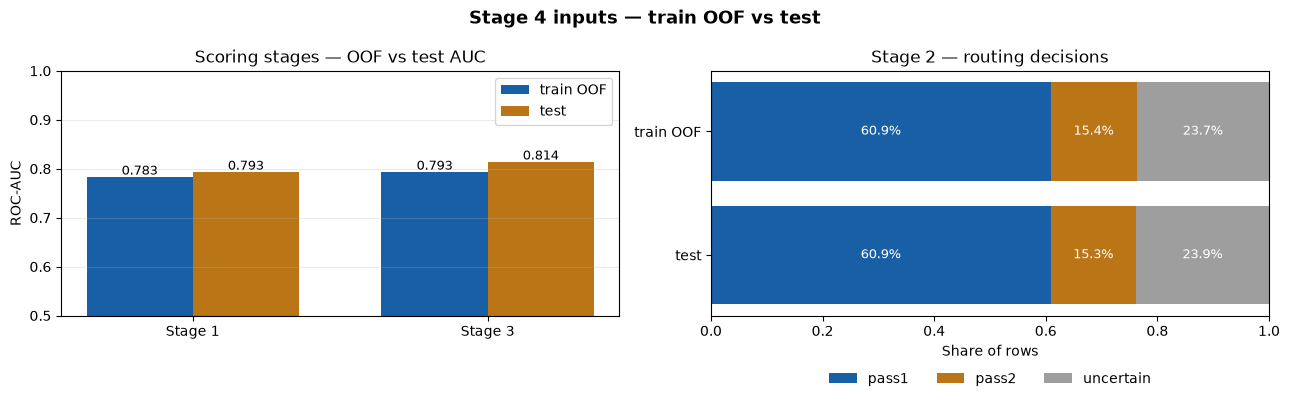

Stage 2 predictions by decision (test)


pred,-1,0,1
decision,,,
pass1,0,5013,0
pass2,0,0,1260
uncertain,1965,0,0



✅ all 31 validation checks passed — Stage 4 inputs ready


In [46]:
# ============================================================
# CELL 42: STAGE 4 HAND-OFF SUMMARY
# ============================================================
import matplotlib.pyplot as plt

STAGE4_SCORERS = pd.DataFrame([
    {"stage": name,
     "threshold (test)": float(s["t_te"]()),
     "OOF AUC": roc_auc_score(_Y_TR, s["p_tr"]()),
     "test AUC": roc_auc_score(_Y_TE, s["p_te"]()),
     "OOF flag rate": float(np.mean(np.asarray(s["d_tr"]()))),
     "test flag rate": float(np.mean(np.asarray(s["d_te"]())))}
    for name, s in _SCORERS.items()
]).set_index("stage")


def _route_summary(side, y, ab):
    d = _S2[f"decisions_{side}"]
    return {"side": "train OOF" if side == "train_oof" else "test",
            **{k: v for k, v in d.value_counts(normalize=True).sort_index().items()},
            "abstain base rate": float(y[_S2[ab]].mean()),
            "overall base rate": float(y.mean())}


STAGE4_ROUTER = pd.DataFrame([_route_summary("train_oof", _Y_TR, "abstain_train"),
                              _route_summary("test", _Y_TE, "abstain_test")]).set_index("side")

print(f"split fingerprint {_FP} — shared by Stages 1–3\n")
print("Scoring stages (1, 3)")
display(STAGE4_SCORERS.style.format("{:.4f}"))
print(f"Routing stage (2): t1={_S2['t1']:.4f}, t2={_S2['t2']:.4f}")
display(STAGE4_ROUTER.style.format("{:.4f}"))

# ---- visual: signal quality and Stage 2 routing, train OOF vs test ----
_routes = [c for c in STAGE4_ROUTER.columns if "base rate" not in c]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
fig.suptitle("Stage 4 inputs — train OOF vs test", fontsize=13, fontweight="bold")

_x = np.arange(len(STAGE4_SCORERS))
ax1.bar(_x - 0.18, STAGE4_SCORERS["OOF AUC"], 0.36, label="train OOF", color="#185FA5")
ax1.bar(_x + 0.18, STAGE4_SCORERS["test AUC"], 0.36, label="test", color="#BA7517")
for i, (a, b) in enumerate(zip(STAGE4_SCORERS["OOF AUC"], STAGE4_SCORERS["test AUC"])):
    ax1.text(i - 0.18, a + 0.005, f"{a:.3f}", ha="center", fontsize=9)
    ax1.text(i + 0.18, b + 0.005, f"{b:.3f}", ha="center", fontsize=9)
ax1.set(xticks=_x, xticklabels=STAGE4_SCORERS.index, ylabel="ROC-AUC",
        ylim=(0.5, 1.0), title="Scoring stages — OOF vs test AUC")
ax1.legend(loc="upper right"); ax1.grid(axis="y", alpha=0.25)

_left = np.zeros(len(STAGE4_ROUTER))
_palette = ["#185FA5", "#BA7517", "#9e9e9e", "#5b8e7d"]
for j, r in enumerate(_routes):
    vals = STAGE4_ROUTER[r].fillna(0).values
    ax2.barh(STAGE4_ROUTER.index, vals, left=_left, color=_palette[j % 4], label=r)
    for k, (l, v) in enumerate(zip(_left, vals)):
        if v > 0.06:
            ax2.text(l + v / 2, k, f"{v:.1%}", ha="center", va="center", color="white", fontsize=9)
    _left += vals
ax2.set(xlim=(0, 1), xlabel="Share of rows", title="Stage 2 — routing decisions")
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=len(_routes), frameon=False)
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

print("Stage 2 predictions by decision (test)")
display(pd.crosstab(_S2["decisions_test"], _S2["preds_test"],
                    rownames=["decision"], colnames=["pred"]))
print(f"\n✅ all {len(VALIDATION.rows)} validation checks passed — Stage 4 inputs ready")